In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn import naive_bayes
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer

In [3]:
import re, nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from collections import Counter

[nltk_data] Downloading package punkt to C:\Users\Samson
[nltk_data]     Silvester\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Samson
[nltk_data]     Silvester\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\Samson
[nltk_data]     Silvester\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Samson
[nltk_data]     Silvester\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Samson
[nltk_data]     Silvester\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
df = pd.read_csv('Tweets.csv')
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [5]:
df.ndim

2

In [6]:
df.shape

(14640, 15)

In [7]:
df.isna().sum()/len(df)*100

tweet_id                         0.000000
airline_sentiment                0.000000
airline_sentiment_confidence     0.000000
negativereason                  37.308743
negativereason_confidence       28.128415
airline                          0.000000
airline_sentiment_gold          99.726776
name                             0.000000
negativereason_gold             99.781421
retweet_count                    0.000000
text                             0.000000
tweet_coord                     93.039617
tweet_created                    0.000000
tweet_location                  32.329235
user_timezone                   32.923497
dtype: float64

In [8]:
df.drop_duplicates(inplace = True)

In [9]:
df.drop('airline_sentiment_gold',axis = 1,inplace = True)
df.drop('negativereason_gold',axis = 1,inplace = True)
df.drop('tweet_coord',axis = 1, inplace = True)

In [10]:
df['negativereason'] = df['negativereason'].fillna('Others')
df['negativereason_confidence'] = df['negativereason_confidence'].fillna(df['negativereason_confidence'].mean())
df['tweet_location'].fillna('No location',inplace = True)
df['user_timezone'].fillna('No Timezone',inplace = True)

C:\Users\Samson Silvester\AppData\Local\Temp\ipykernel_20788\2263697168.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['tweet_location'].fillna('No location',inplace = True)
C:\Users\Samson Silvester\AppData\Local\Temp\ipykernel_20788\2263697168.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alw

In [11]:
df[['Sub_airline', 'Comments']] = df['text'].str.split(' ', n=1, expand=True)
correct_air = df['Sub_airline'] == df['airline']
correct_air.value_counts()

False    14604
Name: count, dtype: int64

In [12]:
df.drop('text',axis = 1, inplace = True)
df.drop('Sub_airline',axis = 1, inplace = True)
df.drop('Comments',axis = 1, inplace = True)


In [13]:
df.isna().sum()/len(df)*100

tweet_id                        0.0
airline_sentiment               0.0
airline_sentiment_confidence    0.0
negativereason                  0.0
negativereason_confidence       0.0
airline                         0.0
name                            0.0
retweet_count                   0.0
tweet_created                   0.0
tweet_location                  0.0
user_timezone                   0.0
dtype: float64

In [14]:
df.describe()

,tweet_id,airline_sentiment_confidence,negativereason_confidence,retweet_count
count,1.460400e+04,14604.000000,14604.000000,14604.000000
mean,5.692157e+17,0.899923,0.637644,0.082786
std,7.782567e+14,0.162955,0.280174,0.746647
min,5.675883e+17,0.335000,0.000000,0.000000
25%,5.685581e+17,0.692300,0.637644,0.000000
50%,5.694728e+17,1.000000,0.637644,0.000000
75%,5.698885e+17,1.000000,0.703000,0.000000
max,5.703106e+17,1.000000,1.000000,44.000000


In [15]:
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,name,retweet_count,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,Others,0.637644,Virgin America,cairdin,0,2015-02-24 11:35:52 -0800,No location,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,Others,0.000000,Virgin America,jnardino,0,2015-02-24 11:15:59 -0800,No location,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,Others,0.637644,Virgin America,yvonnalynn,0,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.703300,Virgin America,jnardino,0,2015-02-24 11:15:36 -0800,No location,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.000000,Virgin America,jnardino,0,2015-02-24 11:14:45 -0800,No location,Pacific Time (US & Canada)


In [16]:
pd.crosstab(df['airline'],df['negativereason'])

negativereason,Bad Flight,Can't Tell,Cancelled Flight,Customer Service Issue,Damaged Luggage,Flight Attendant Complaints,Flight Booking Problems,Late Flight,Lost Luggage,Others,longlines
airline,,,,,,,,,,,
American,87,198,242,762,12,86,130,244,146,782,34
Delta,64,186,51,199,11,60,44,269,57,1267,14
Southwest,90,159,162,391,14,38,61,152,90,1234,29
US Airways,104,246,189,811,11,123,122,453,154,650,50
United,216,379,181,681,22,168,144,525,269,1189,48
Virgin America,19,22,18,60,4,5,28,17,5,323,3


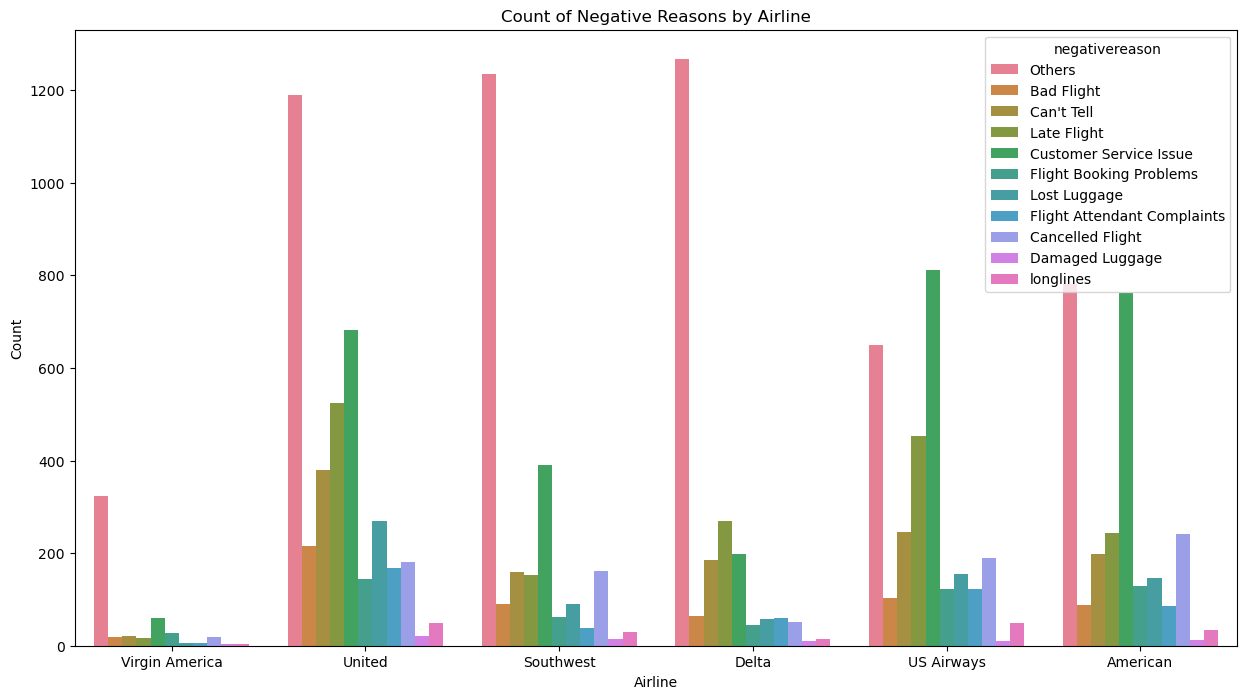

In [17]:
fig = plt.figure(figsize=(15,8))
sns.countplot(x = 'airline',hue = 'negativereason',data = df)
plt.title('Count of Negative Reasons by Airline')
plt.xlabel('Airline')
plt.ylabel('Count')
plt.show()

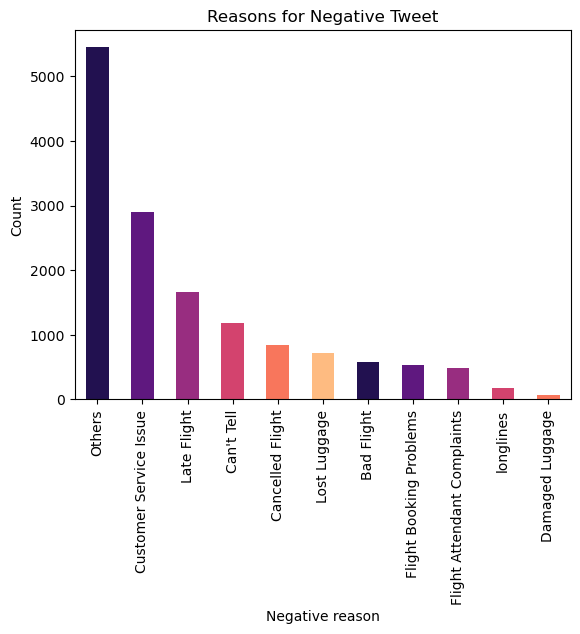

                 negativereason  count
0                        Others   5445
1        Customer Service Issue   2904
2                   Late Flight   1660
3                    Can't Tell   1190
4              Cancelled Flight    843
5                  Lost Luggage    721
6                    Bad Flight    580
7       Flight Booking Problems    529
8   Flight Attendant Complaints    480
9                     longlines    178
10              Damaged Luggage     74


In [18]:
df['negativereason'].value_counts().plot(kind = 'bar',color = sns.color_palette('magma'))
plt.title('Reasons for Negative Tweet')
plt.xlabel('Negative reason')
plt.ylabel('Count')
plt.show()
print(df['negativereason'].value_counts().reset_index())

Airline with highest proportion of positive tweets: Virgin America
Airline with highest proportion of negative tweets: US Airways

Proportion of sentiments per airline:
airline_sentiment         airline   negative    neutral   positive
0                        American  71.281675  16.709512  12.008814
1                           Delta  42.979298  32.538254  24.482448
2                       Southwest  49.008264  27.438017  23.553719
3                      US Airways  77.686234  13.079300   9.234466
4                          United  68.890633  18.236525  12.872841
5                  Virgin America  35.912698  33.928571  30.158730


<Figure size 1500x800 with 0 Axes>

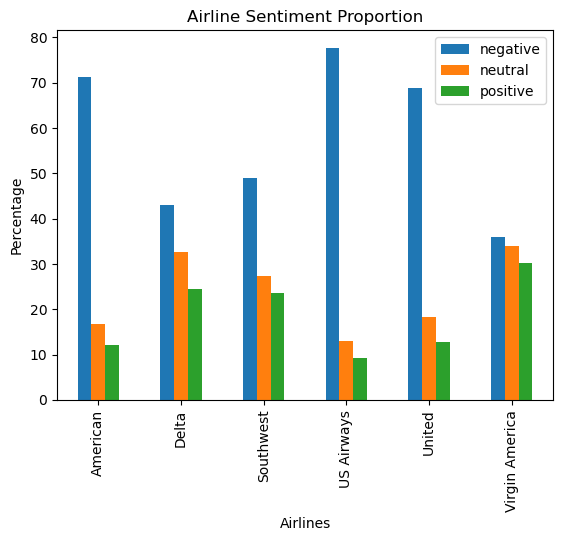

In [19]:
airline_sentiment_counts = df.groupby(['airline', 'airline_sentiment']).size().unstack(fill_value=0)
airline_sentiment_proportions = airline_sentiment_counts.apply(lambda x: x / x.sum()*100, axis=1)

# Highest proportion of positive sentiment tweets
most_positive_airline = airline_sentiment_proportions['positive'].idxmax()
print(f"Airline with highest proportion of positive tweets: {most_positive_airline}")

# Highest proportion of negative sentiment tweets
most_negative_airline = airline_sentiment_proportions['negative'].idxmax()
print(f"Airline with highest proportion of negative tweets: {most_negative_airline}")

# Optionally, display the full proportion table
print("\nProportion of sentiments per airline:")
print(airline_sentiment_proportions.reset_index())

figure=plt.figure(figsize=(15,8))
airline_sentiment_proportions.plot(kind = 'bar',color = sns.color_palette('tab10'))
plt.title('Airline Sentiment Proportion')
plt.xlabel('Airlines')
plt.xticks(rotation = 90)
plt.ylabel('Percentage')
plt.legend()
plt.show()


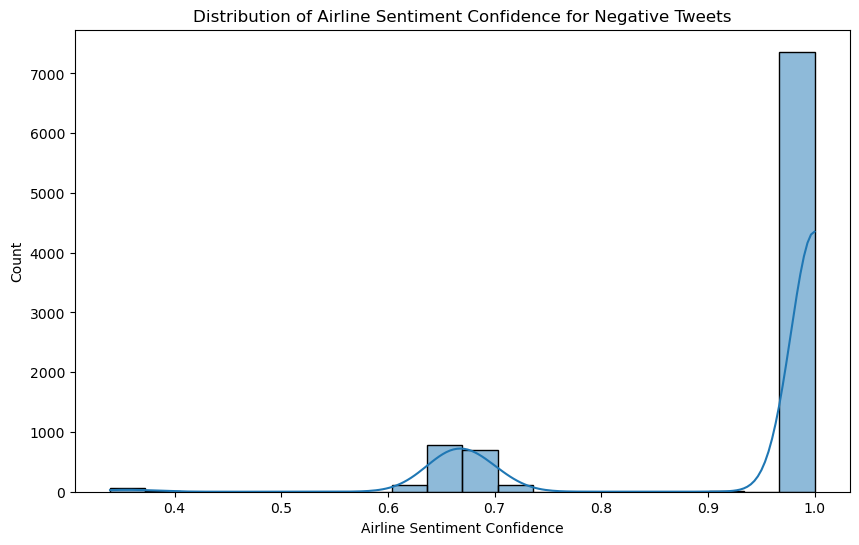


Correlation between airline_sentiment_confidence and likelihood of a tweet being negative: 0.2650775585264527
There is a weak positive correlation, suggesting higher confidence might be slightly associated with negative tweets.

Mean Airline Sentiment Confidence by Sentiment
	


,airline_sentiment,airline_sentiment_confidence
0,negative,0.933227
1,neutral,0.822846
2,positive,0.871550


In [20]:
negative_tweets_df = df[df['airline_sentiment'] == 'negative']

# Plotting the distribution of airline_sentiment_confidence for negative tweets
plt.figure(figsize=(10, 6))
sns.histplot(negative_tweets_df['airline_sentiment_confidence'], bins=20, kde=True)
plt.title('Distribution of Airline Sentiment Confidence for Negative Tweets')
plt.xlabel('Airline Sentiment Confidence')
plt.ylabel('Count')
plt.show()

# Calculate the correlation between airline_sentiment_confidence and whether a tweet is negative
df['is_negative'] = (df['airline_sentiment'] == 'negative').astype(int)

# Calculating the correlation coefficient
correlation = df['airline_sentiment_confidence'].corr(df['is_negative'])
print(f"\nCorrelation between airline_sentiment_confidence and likelihood of a tweet being negative: {correlation}")

# Interpreting the correlation coefficient:
if correlation > 0.1:
    print("There is a weak positive correlation, suggesting higher confidence might be slightly associated with negative tweets.")
elif correlation < -0.1:
    print("There is a weak negative correlation, suggesting higher confidence might be slightly associated with non-negative tweets.")
else:
    print("There is a very weak or no linear correlation.")

  # Also, we can look at the mean confidence for different sentiment categories
mean_confidence_by_sentiment = df.groupby('airline_sentiment')['airline_sentiment_confidence'].mean()
print("\nMean Airline Sentiment Confidence by Sentiment")
print('\t')
mean_confidence_by_sentiment.reset_index()

In [21]:
location_sentiment = df.groupby(['tweet_location', 'airline_sentiment']).size().unstack(fill_value=0)
timezone_sentiment = df.groupby(['user_timezone', 'airline_sentiment']).size().unstack(fill_value=0)

min_tweets = 50
location_sentiment_filtered = location_sentiment[(location_sentiment['negative'] + location_sentiment['neutral'] + location_sentiment['positive']) >= min_tweets]
timezone_sentiment_filtered = timezone_sentiment[(timezone_sentiment['negative'] + timezone_sentiment['neutral'] + timezone_sentiment['positive']) >= min_tweets]

print("\nSentiment distribution by Tweet Location (filtered for locations with >= 50 tweets):")
print(location_sentiment_filtered)

print("\nSentiment distribution by User Timezone (filtered for timezones with >= 50 tweets):")
print(timezone_sentiment_filtered)


Sentiment distribution by Tweet Location (filtered for locations with >= 50 tweets):
airline_sentiment  negative  neutral  positive
tweet_location                                
Austin, TX               42       11        11
Boston                   34       19         9
Boston, MA              103       35        19
Brooklyn, NY             47       10         9
Chicago                  68       18        18
Chicago, IL              56       16         9
Dallas, TX               25       16        13
Los Angeles              39       11        14
Los Angeles, CA          62       16        18
NYC                      68       14        13
New York                 86       22        19
New York City            60       21        15
New York, NY             93       30        33
No location            3135      960       628
San Francisco            57       12        17
San Francisco, CA        63       15        13
USA                      33       74        18
Washington DC        

In [22]:
location_sentiment_proportions = location_sentiment_filtered.apply(lambda x: x / x.sum()*100, axis=1)
timezone_sentiment_proportions = timezone_sentiment_filtered.apply(lambda x: x / x.sum()*100, axis=1)

print("\nProportion of Sentiment by Tweet Location (filtered):")
print(location_sentiment_proportions.sort_values(by='negative', ascending=False).head(10))
print(location_sentiment_proportions.sort_values(by='positive', ascending=False).head(10))
print('\n')
print("\nProportion of Sentiment by User Timezone (filtered):")
print(timezone_sentiment_proportions.sort_values(by='negative', ascending=False).head(10))
print(timezone_sentiment_proportions.sort_values(by='positive', ascending=False).head(10))


Proportion of Sentiment by Tweet Location (filtered):
airline_sentiment   negative    neutral   positive
tweet_location                                    
Washington DC      79.245283  11.320755   9.433962
Washington, DC     73.648649  10.135135  16.216216
NYC                71.578947  14.736842  13.684211
Brooklyn, NY       71.212121  15.151515  13.636364
San Francisco, CA  69.230769  16.483516  14.285714
Chicago, IL        69.135802  19.753086  11.111111
New York           67.716535  17.322835  14.960630
Washington, D.C.   66.666667  19.047619  14.285714
No location        66.377303  20.326064  13.296633
San Francisco      66.279070  13.953488  19.767442
airline_sentiment   negative    neutral   positive
tweet_location                                    
Dallas, TX         46.296296  29.629630  24.074074
Los Angeles        60.937500  17.187500  21.875000
New York, NY       59.615385  19.230769  21.153846
San Francisco      66.279070  13.953488  19.767442
Los Angeles, CA    64.58333

In [23]:
location_negativereason = df.groupby(['tweet_location', 'negativereason']).size().unstack(fill_value=0)
timezone_negativereason = df.groupby(['user_timezone', 'negativereason']).size().unstack(fill_value=0)

min_negative_tweets_for_analysis = 50
location_negativereason_filtered = location_negativereason[location_negativereason.sum(axis=1) >= min_negative_tweets_for_analysis]
timezone_negativereason_filtered = timezone_negativereason[timezone_negativereason.sum(axis=1) >= min_negative_tweets_for_analysis]

print("\nDistribution of Negative Reasons by Tweet Location (filtered for locations with >= 50 negative tweets):")
print(location_negativereason_filtered.apply(lambda x: x / x.sum(), axis=1).head())

print("\nDistribution of Negative Reasons by User Timezone (filtered for timezones with >= 50 negative tweets):")
print(timezone_negativereason_filtered.apply(lambda x: x / x.sum(), axis=1).head())


Distribution of Negative Reasons by Tweet Location (filtered for locations with >= 50 negative tweets):
negativereason  Bad Flight  Can't Tell  Cancelled Flight  \
tweet_location                                             
Austin, TX        0.046875    0.093750          0.046875   
Boston            0.032258    0.048387          0.032258   
Boston, MA        0.050955    0.082803          0.038217   
Brooklyn, NY      0.030303    0.075758          0.015152   
Chicago           0.067308    0.134615          0.028846   

negativereason  Customer Service Issue  Damaged Luggage  \
tweet_location                                            
Austin, TX                    0.265625         0.000000   
Boston                        0.177419         0.000000   
Boston, MA                    0.184713         0.012739   
Brooklyn, NY                  0.272727         0.000000   
Chicago                       0.153846         0.009615   

negativereason  Flight Attendant Complaints  Flight Booking 

In [24]:
# To see if they vary significantly, we can look at the top reasons in different locations/timezones
print("\nTop negative reasons by location (showing top 5 locations by total negative tweets):")
for location in location_negativereason_filtered.sum(axis=1).sort_values(ascending=False).head(5).index:
   print(f"\nLocation: {location}")
   print(location_negativereason_filtered.loc[location].sort_values(ascending=False).head(5))

   print("\nTop negative reasons by timezone (showing top 5 timezones by total negative tweets):")
   for timezone in timezone_negativereason_filtered.sum(axis=1).sort_values(ascending=False).head(5).index:
    print(f"\nTimezone: {timezone}")
    print(timezone_negativereason_filtered.loc[timezone].sort_values(ascending=False).head(5))


Top negative reasons by location (showing top 5 locations by total negative tweets):

Location: No location
negativereason
Others                    1588
Customer Service Issue    1027
Late Flight                559
Can't Tell                 386
Cancelled Flight           321
Name: No location, dtype: int64

Top negative reasons by timezone (showing top 5 timezones by total negative tweets):

Timezone: No Timezone
negativereason
Others                    1649
Customer Service Issue    1005
Late Flight                591
Can't Tell                 411
Cancelled Flight           292
Name: No Timezone, dtype: int64

Timezone: Eastern Time (US & Canada)
negativereason
Others                    1428
Customer Service Issue     723
Late Flight                441
Can't Tell                 290
Cancelled Flight           224
Name: Eastern Time (US & Canada), dtype: int64

Timezone: Central Time (US & Canada)
negativereason
Others                    735
Customer Service Issue    390
Late Fligh

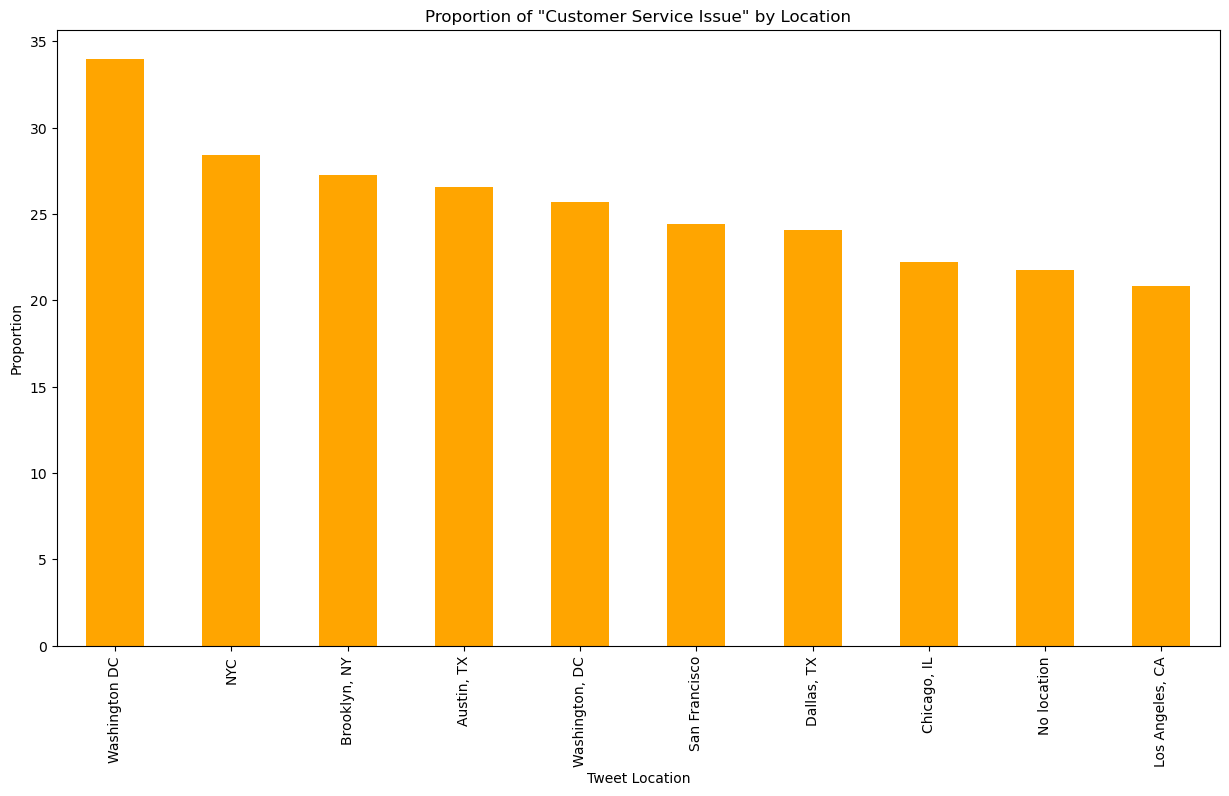

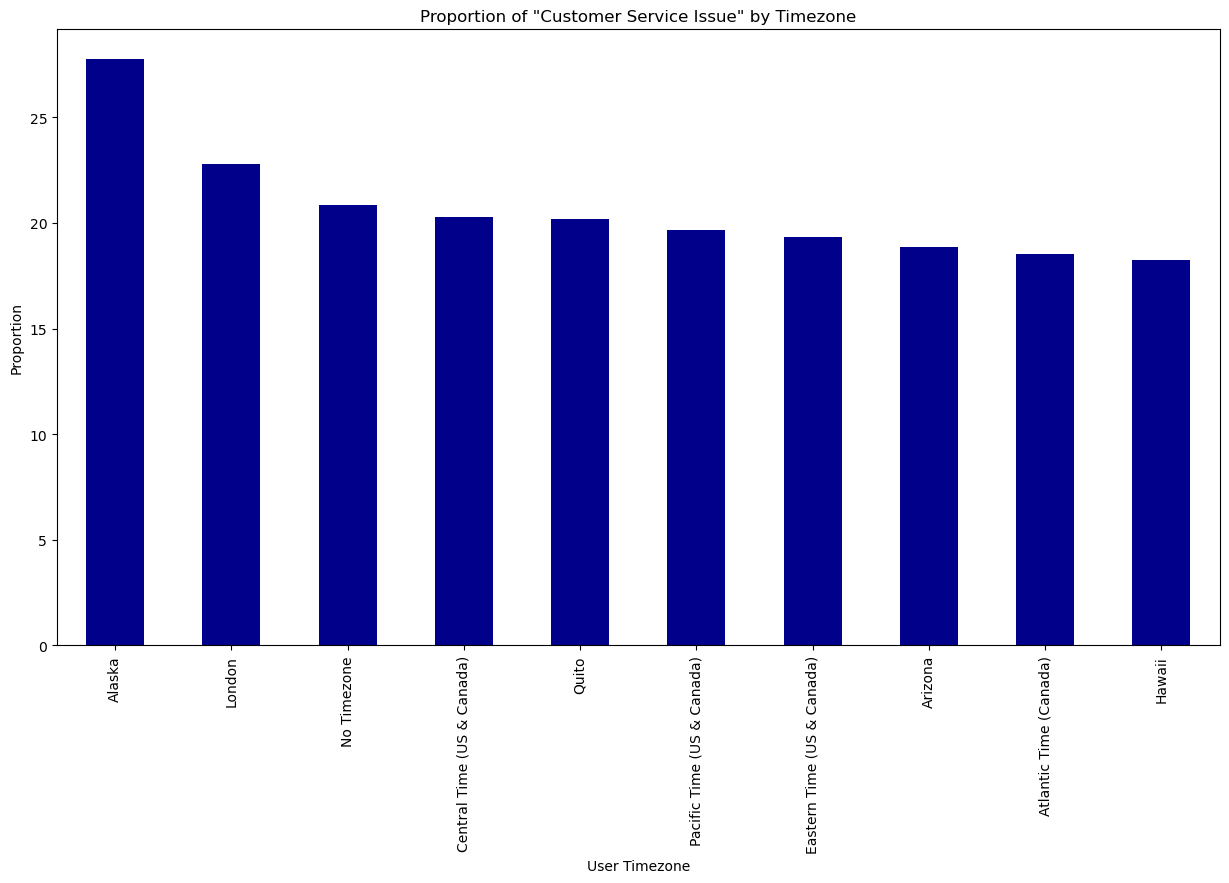

In [25]:
negative_reason_to_compare = 'Customer Service Issue'
if negative_reason_to_compare in location_negativereason_filtered.columns:
    plt.figure(figsize=(15, 8))
    location_negativereason_filtered.apply(lambda x: x / x.sum()*100, axis=1)[negative_reason_to_compare].sort_values(ascending=False).head(10).plot(kind='bar',color = 'orange')
    plt.title(f'Proportion of "{negative_reason_to_compare}" by Location')
    plt.xlabel('Tweet Location')
    plt.ylabel('Proportion')
    plt.xticks(rotation=90)
    plt.show()

if negative_reason_to_compare in timezone_negativereason_filtered.columns:
    plt.figure(figsize=(15, 8))
    timezone_negativereason_filtered.apply(lambda x: x / x.sum()*100, axis=1)[negative_reason_to_compare].sort_values(ascending=False).head(10).plot(kind='bar',color = 'darkblue')
    plt.title(f'Proportion of "{negative_reason_to_compare}" by Timezone')
    plt.xlabel('User Timezone')
    plt.ylabel('Proportion')
    plt.xticks(rotation=90)
    plt.show()


Analyzing sentiment performance for American in specific locations:

Top 10 locations for American with highest positive sentiment proportion:
airline_sentiment   positive   negative    neutral
tweet_location                                    
Los Angeles        30.000000  65.000000   5.000000
Texas              28.571429  52.380952  19.047619
Chicago, IL        19.047619  66.666667  14.285714
San Diego          15.000000  60.000000  25.000000
Dallas, TX         15.000000  55.000000  30.000000
Los Angeles, CA    14.285714  65.714286  20.000000
Boston, MA         13.043478  56.521739  30.434783
New York, NY       12.820513  76.923077  10.256410
Chicago            12.000000  60.000000  28.000000
New York           10.000000  65.000000  25.000000

Top 10 locations for American with highest negative sentiment proportion:
airline_sentiment   positive    negative    neutral
tweet_location                                     
Pekin               0.000000  100.000000   0.000000
Washington, D

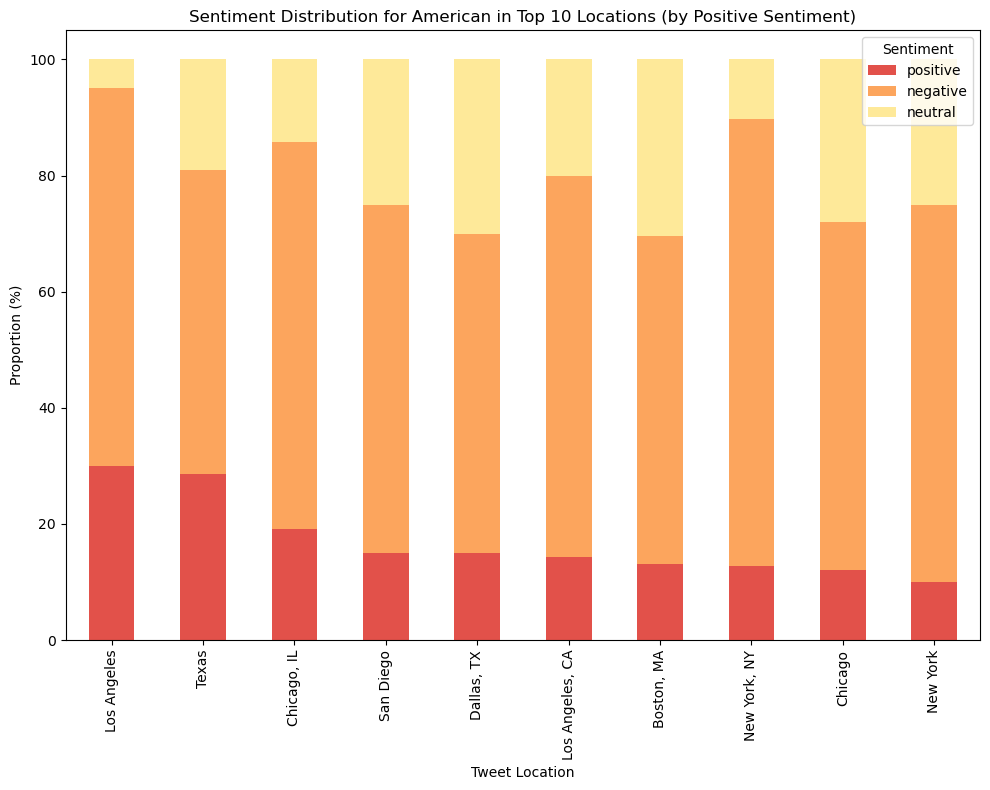

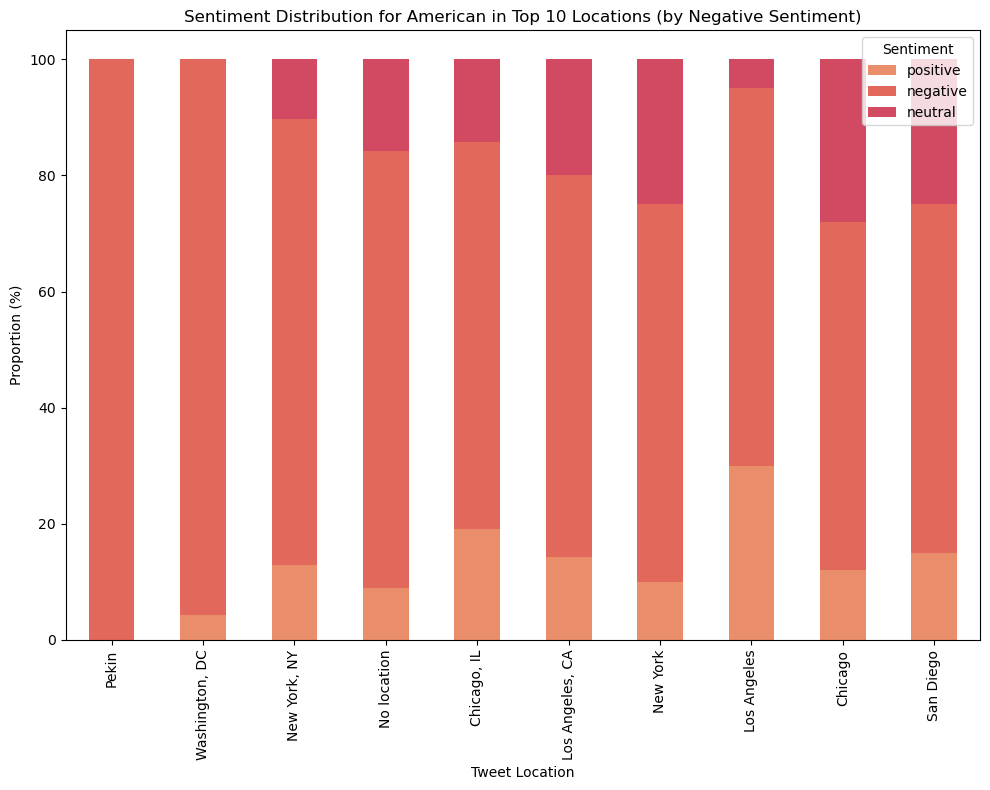


Analyzing sentiment performance for Delta in specific locations:

Top 10 locations for Delta with highest positive sentiment proportion:
airline_sentiment             positive   negative    neutral
tweet_location                                              
New York, NY                 37.037037  35.185185  27.777778
New York                     26.666667  55.555556  17.777778
Brooklyn, NY                 25.925926  51.851852  22.222222
Boston                       25.806452  45.161290  29.032258
NYC                          25.714286  48.571429  25.714286
Washington, DC               25.000000  54.166667  20.833333
No location                  22.330097  51.941748  25.728155
New York City                20.833333  52.083333  27.083333
Logan International Airport  18.750000  12.500000  68.750000
Boston, MA                   16.666667  51.851852  31.481481

Top 10 locations for Delta with highest negative sentiment proportion:
airline_sentiment             positive   negative    neutr

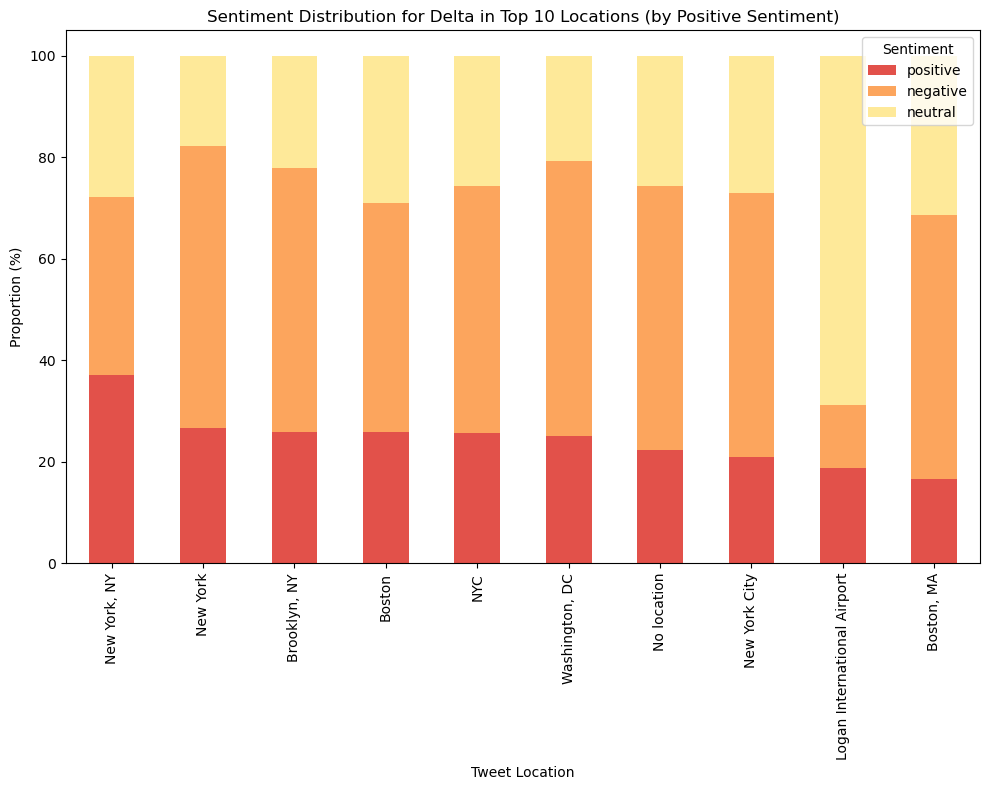

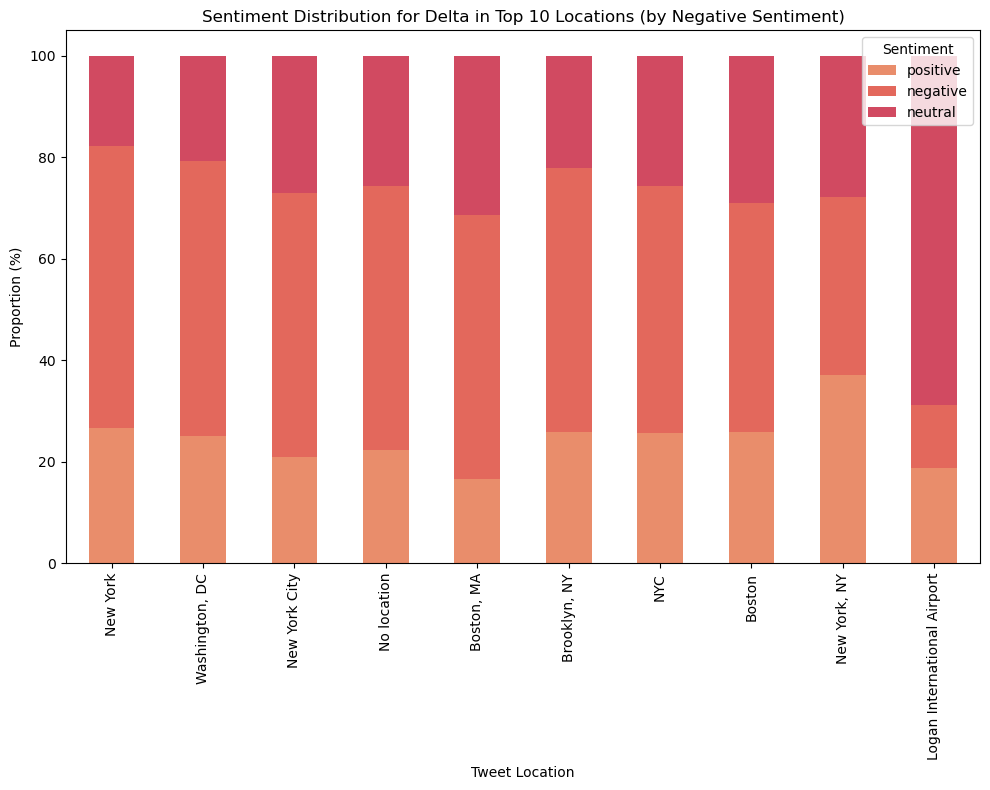


Analyzing sentiment performance for Southwest in specific locations:

Top 10 locations for Southwest with highest positive sentiment proportion:
airline_sentiment   positive   negative    neutral
tweet_location                                    
Nashville, TN      50.000000  36.111111  13.888889
Austin, TX         33.333333  38.095238  28.571429
No location        22.208738  48.665049  29.126214
Chicago            15.625000  65.625000  18.750000
Tallahassee, FL     0.000000  85.714286  14.285714

Top 10 locations for Southwest with highest negative sentiment proportion:
airline_sentiment   positive   negative    neutral
tweet_location                                    
Tallahassee, FL     0.000000  85.714286  14.285714
Chicago            15.625000  65.625000  18.750000
No location        22.208738  48.665049  29.126214
Austin, TX         33.333333  38.095238  28.571429
Nashville, TN      50.000000  36.111111  13.888889


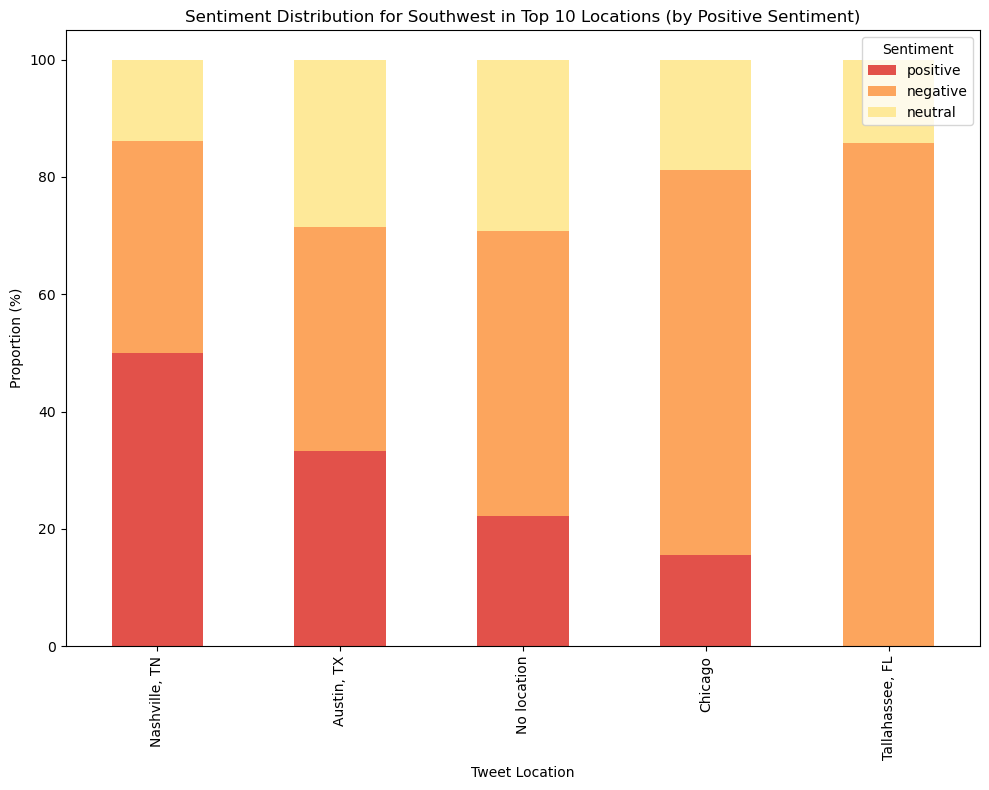

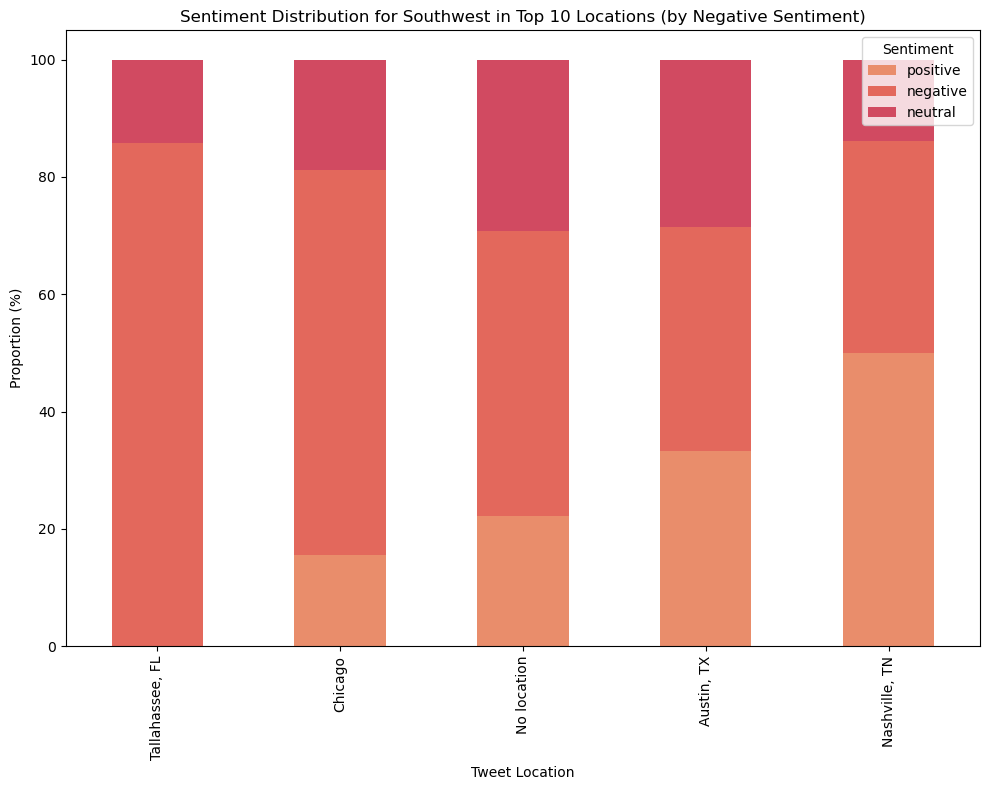


Analyzing sentiment performance for US Airways in specific locations:

Top 10 locations for US Airways with highest positive sentiment proportion:
airline_sentiment   positive   negative    neutral
tweet_location                                    
Washington, DC     12.500000  75.000000  12.500000
Philadelphia, PA   10.000000  75.000000  15.000000
New York            9.523810  80.952381   9.523810
NYC                 9.523810  90.476190   0.000000
Boston, MA          8.333333  86.111111   5.555556
No location         7.670720  78.203929  14.125351
Asheville, NC       4.545455  90.909091   4.545455
Washington, D.C.    2.439024  90.243902   7.317073

Top 10 locations for US Airways with highest negative sentiment proportion:
airline_sentiment   positive   negative    neutral
tweet_location                                    
Asheville, NC       4.545455  90.909091   4.545455
NYC                 9.523810  90.476190   0.000000
Washington, D.C.    2.439024  90.243902   7.317073
Boston, MA

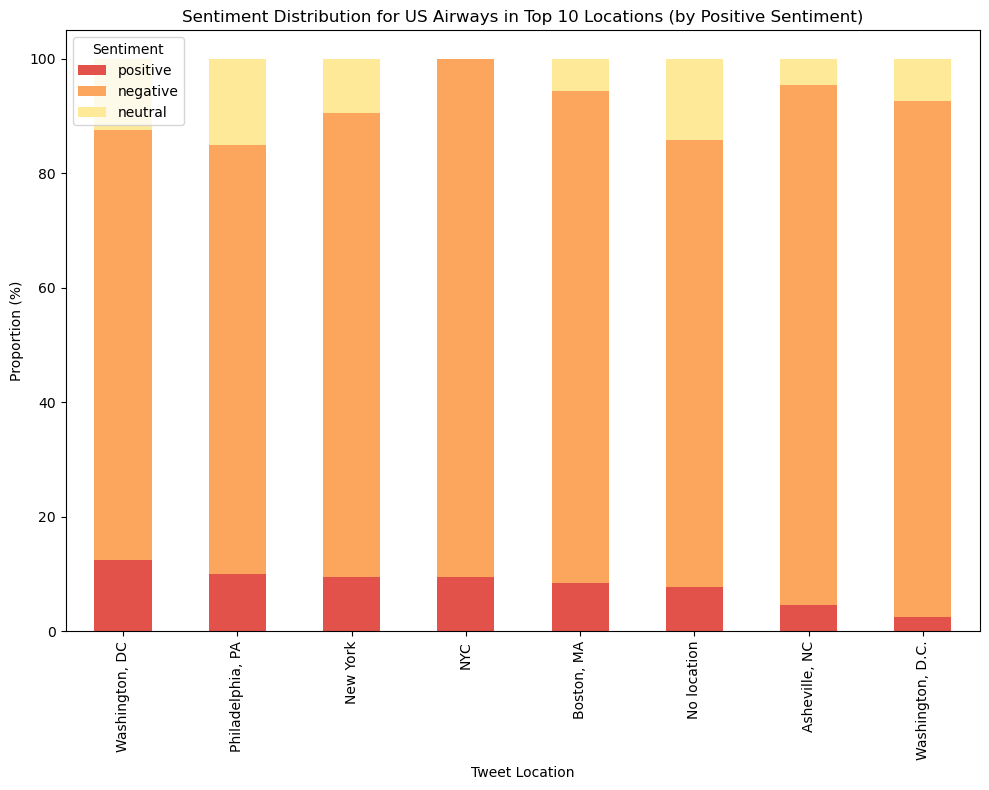

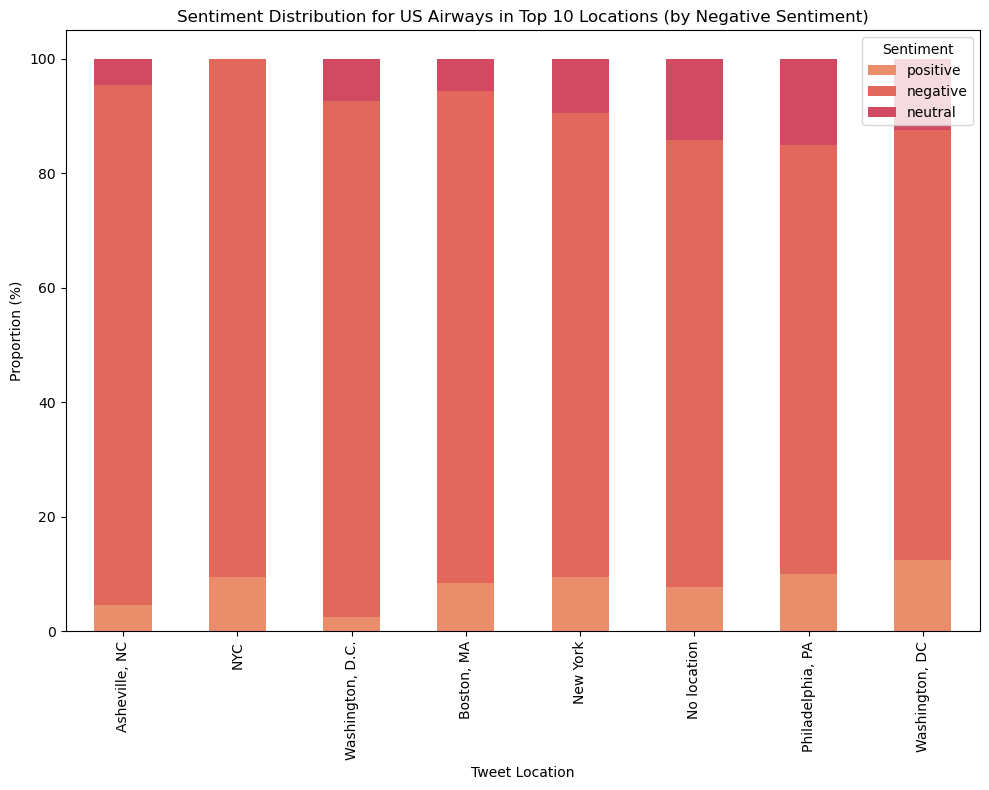


Analyzing sentiment performance for United in specific locations:

Top 10 locations for United with highest positive sentiment proportion:
airline_sentiment   positive   negative    neutral
tweet_location                                    
Chicago            25.000000  69.444444   5.555556
New York, NY       15.625000  71.875000  12.500000
San Francisco      11.764706  79.411765   8.823529
Houston, TX        10.344828  89.655172   0.000000
Washington, DC     10.344828  82.758621   6.896552
No location        10.260723  70.984020  18.755257
San Francisco, CA   9.523810  80.952381   9.523810
Chicago, IL         7.500000  67.500000  25.000000
Boston, MA          7.407407  74.074074  18.518519
Seattle             4.761905  85.714286   9.523810

Top 10 locations for United with highest negative sentiment proportion:
airline_sentiment   positive   negative    neutral
tweet_location                                    
NYC                 0.000000  90.909091   9.090909
Houston, TX        10.

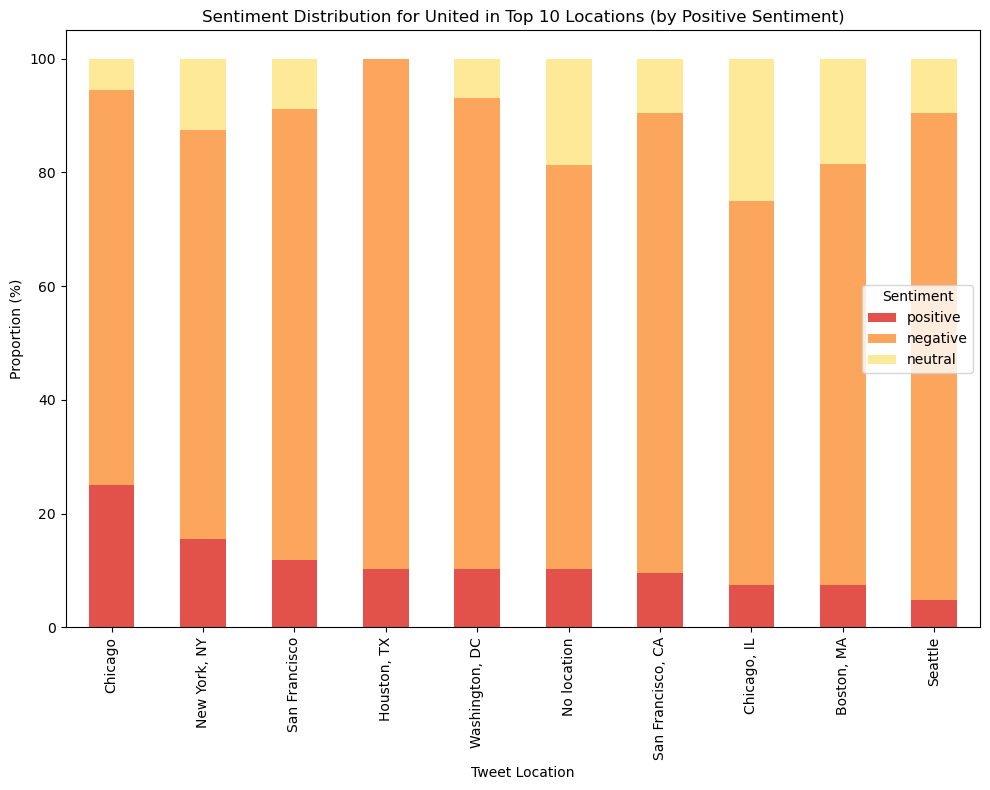

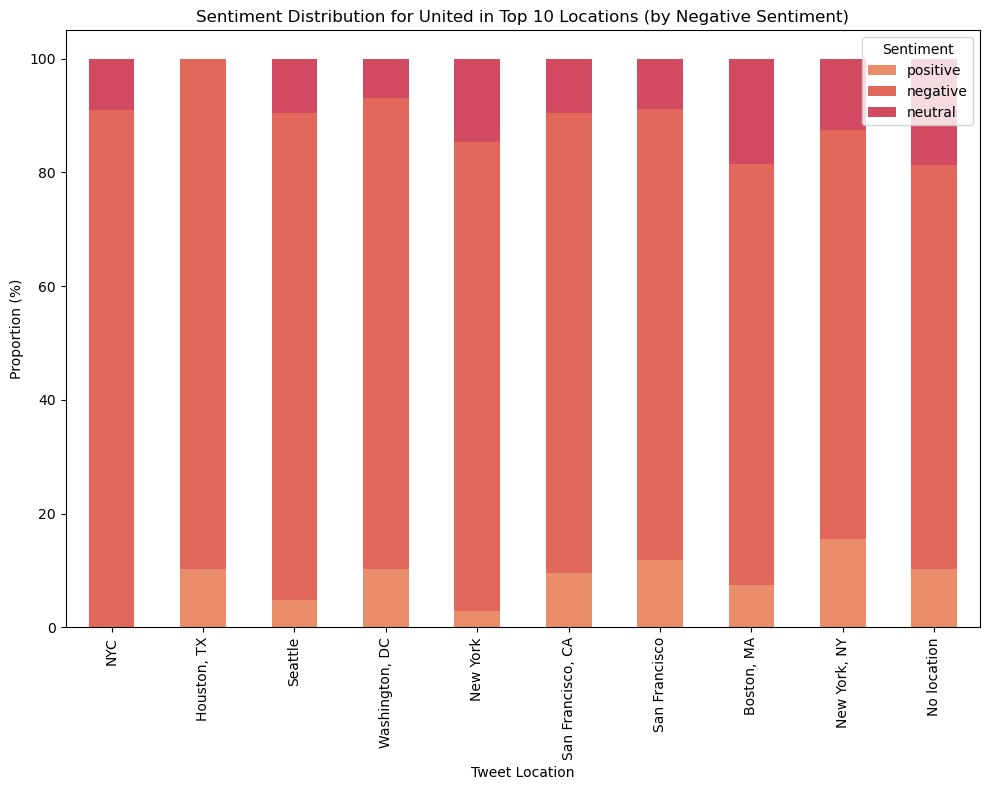


Analyzing sentiment performance for Virgin America in specific locations:

Top 10 locations for Virgin America with highest positive sentiment proportion:
airline_sentiment   positive   negative    neutral
tweet_location                                    
No location        18.032787  45.081967  36.885246

Top 10 locations for Virgin America with highest negative sentiment proportion:
airline_sentiment   positive   negative    neutral
tweet_location                                    
No location        18.032787  45.081967  36.885246


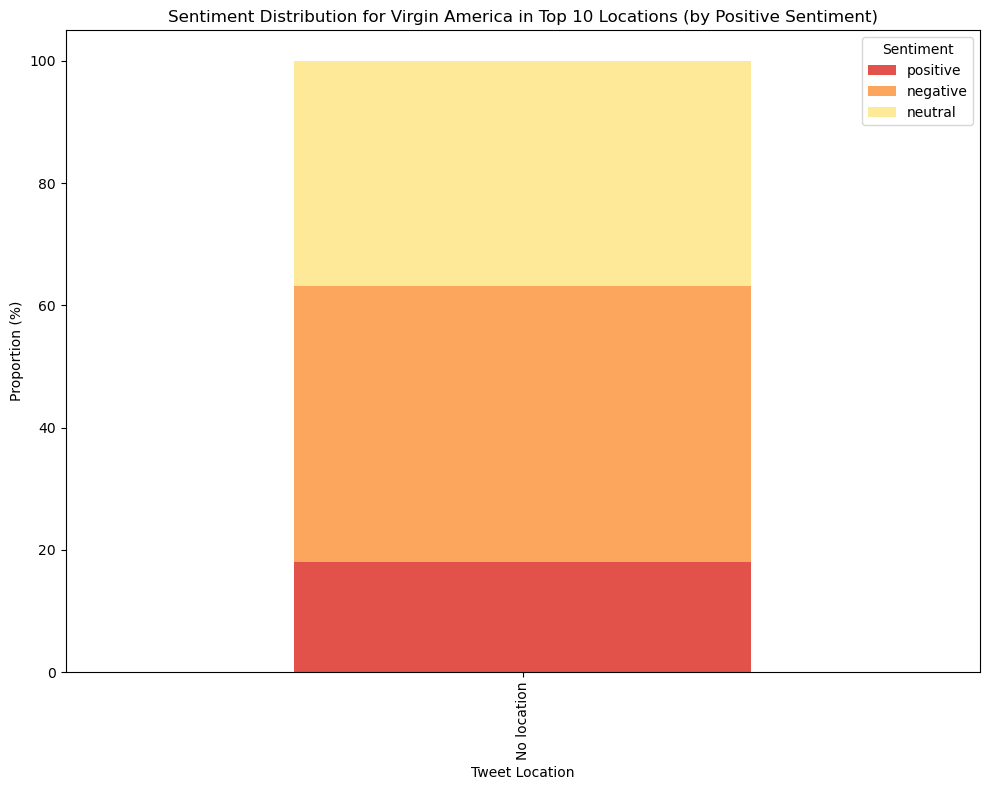

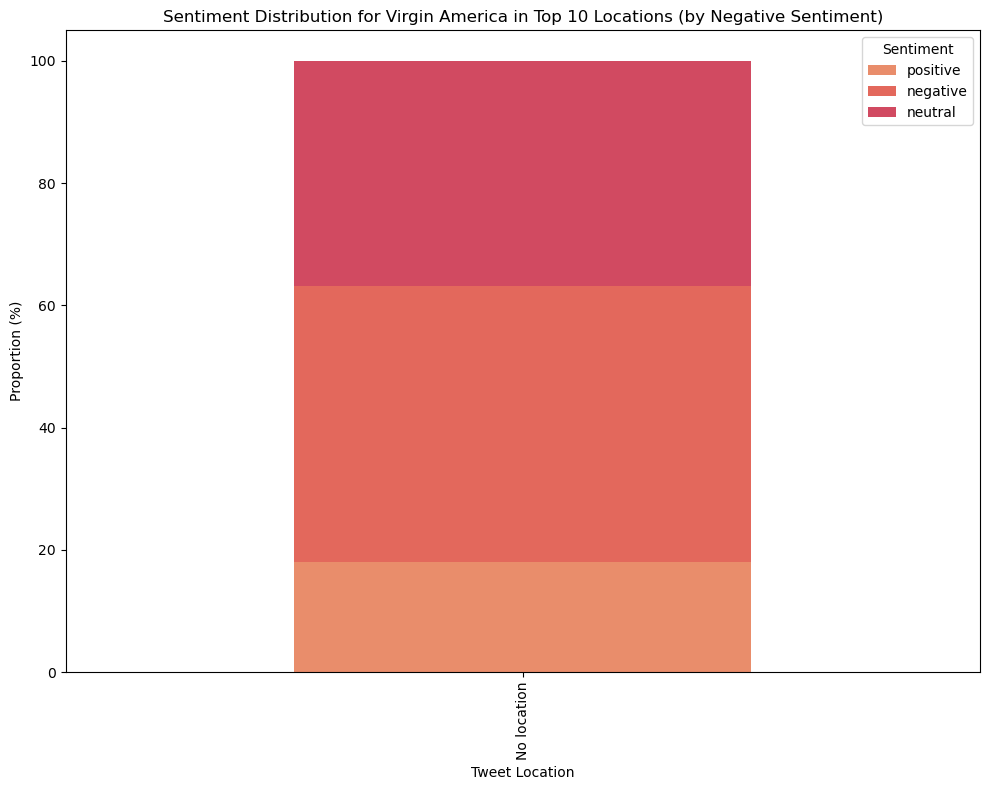

In [26]:
airline_location_sentiment = df.groupby(['airline', 'tweet_location', 'airline_sentiment']).size().unstack(fill_value=0)
min_tweets_location_airline = 20
airline_location_sentiment_filtered = airline_location_sentiment[airline_location_sentiment.sum(axis=1) >= min_tweets_location_airline]
airline_location_sentiment_proportions = airline_location_sentiment_filtered.apply(lambda x: x / x.sum() * 100, axis=1)

# To Analyze sentiment for each airline in specific locations
for airline_to_analyze in airline_location_sentiment_proportions.index.get_level_values('airline').unique():
    print(f"\nAnalyzing sentiment performance for {airline_to_analyze} in specific locations:")
    airline_data = airline_location_sentiment_proportions.loc[airline_to_analyze]

    # Locations with highest positive sentiment proportion for the airline
    top_positive_locations = airline_data.sort_values(by='positive', ascending=False).head(10)
    print(f"\nTop 10 locations for {airline_to_analyze} with highest positive sentiment proportion:")
    print(top_positive_locations[['positive', 'negative', 'neutral']])

    # Locations with highest negative sentiment proportion for the airline
    top_negative_locations = airline_data.sort_values(by='negative', ascending=False).head(10)
    print(f"\nTop 10 locations for {airline_to_analyze} with highest negative sentiment proportion:")
    print(top_negative_locations[['positive', 'negative', 'neutral']])

    if not top_positive_locations.empty:
        plt.figure(figsize=(10, 8))
        top_positive_locations[['positive', 'negative', 'neutral']].plot(kind='bar', stacked=True, ax=plt.gca(), color = sns.color_palette('Spectral'))
        plt.title(f'Sentiment Distribution for {airline_to_analyze} in Top 10 Locations (by Positive Sentiment)')
        plt.xlabel('Tweet Location')
        plt.ylabel('Proportion (%)')
        plt.xticks(rotation=90)
        plt.legend(title='Sentiment')
        plt.tight_layout()
        plt.show()

    if not top_negative_locations.empty:
        plt.figure(figsize=(10, 8))
        top_negative_locations[['positive', 'negative', 'neutral']].plot(kind='bar', stacked=True, ax=plt.gca(), color = sns.color_palette('flare'))
        plt.title(f'Sentiment Distribution for {airline_to_analyze} in Top 10 Locations (by Negative Sentiment)')
        plt.xlabel('Tweet Location')
        plt.ylabel('Proportion (%)')
        plt.xticks(rotation=90)
        plt.legend(title='Sentiment')
        plt.tight_layout()
        plt.show()

C:\Users\Samson Silvester\AppData\Local\Temp\ipykernel_20788\4029404836.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='user_timezone', y='tweet_volume', data=timezone_tweet_volume_filtered.head(top_n_timezones_volume), palette='viridis')


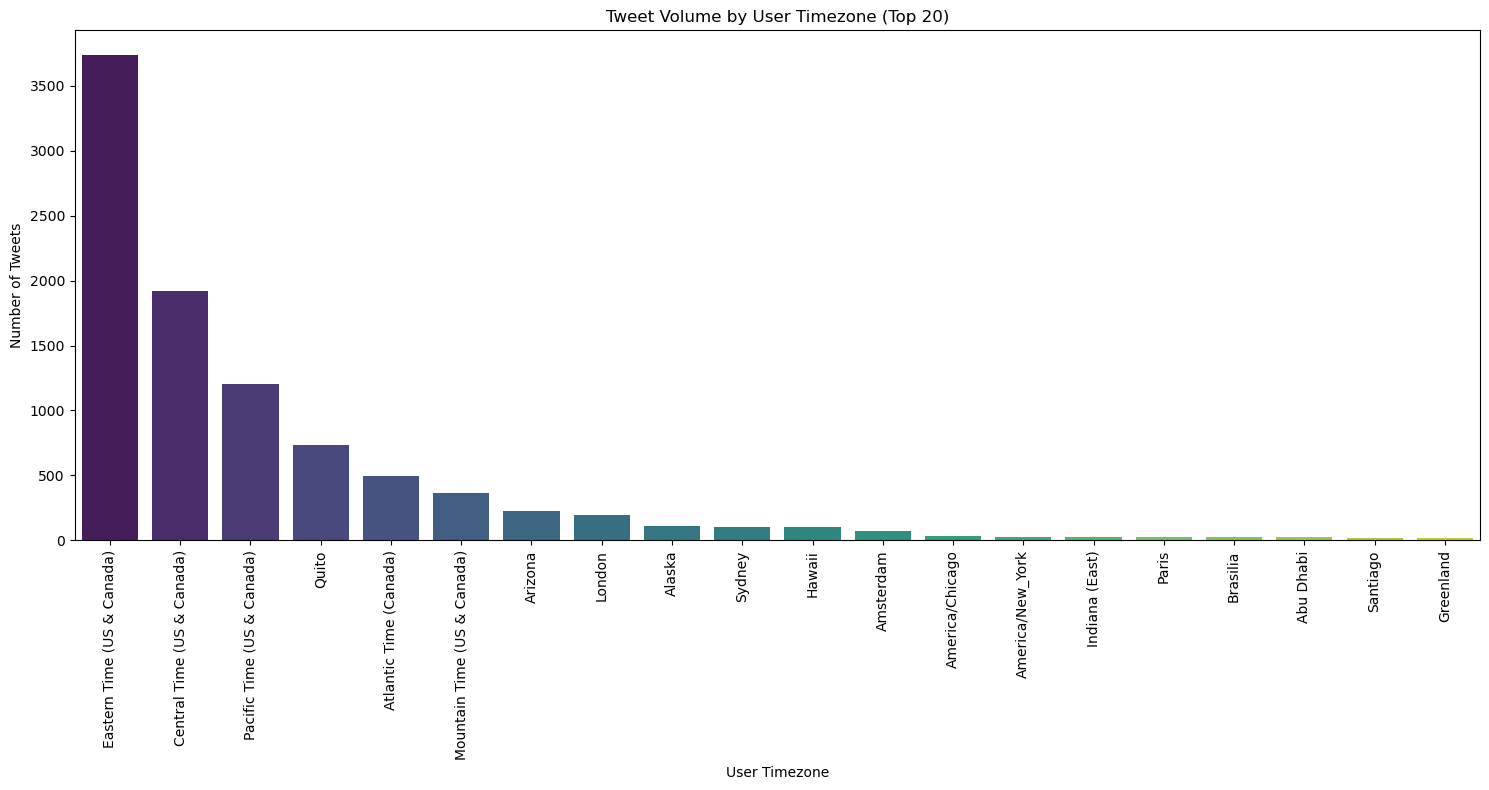

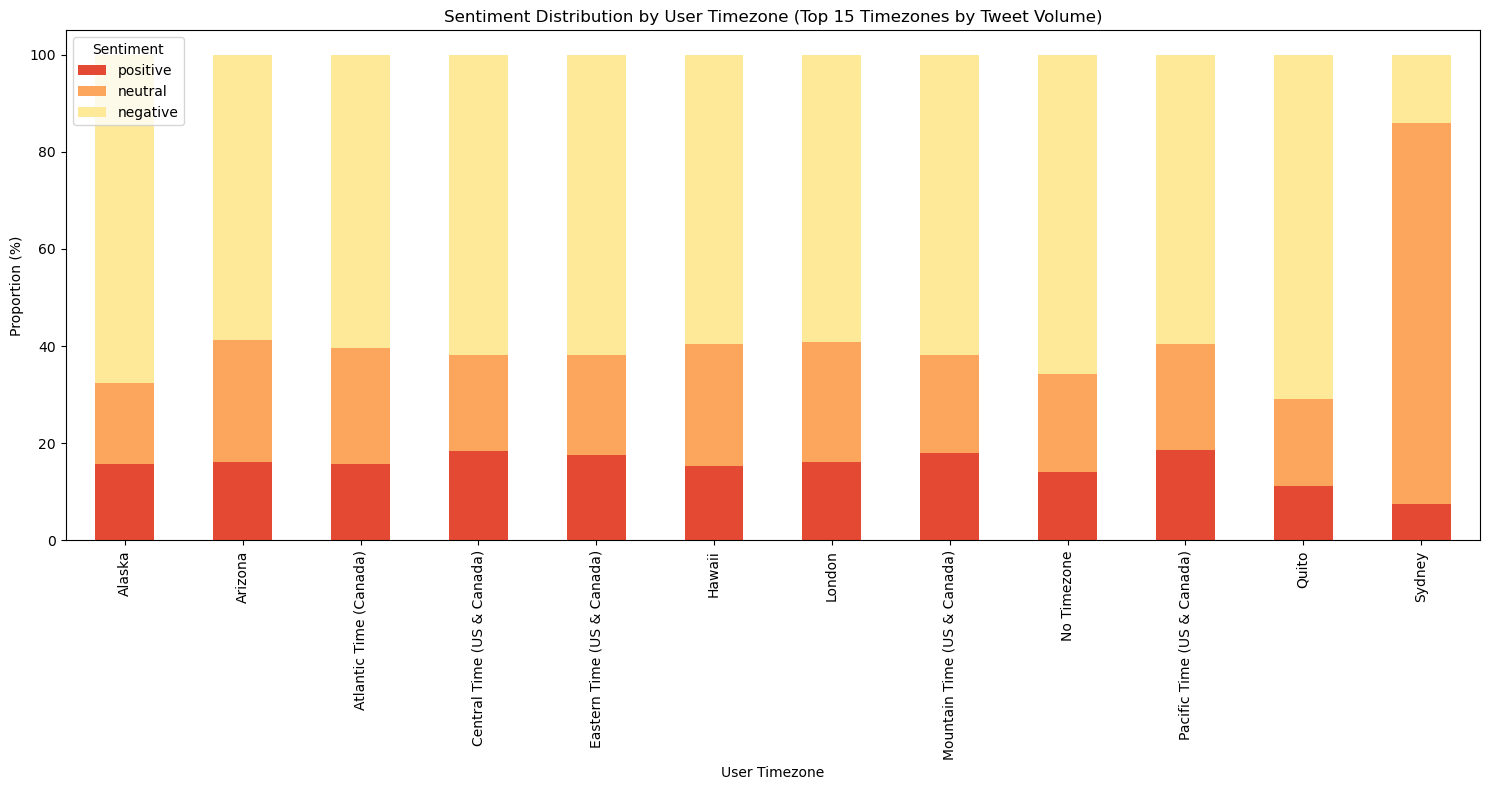


Sentiment Proportion by User Timezone (filtered for timezones with >= 100 tweets):
airline_sentiment            negative    neutral   positive
user_timezone                                              
Quito                       70.804911  18.008186  11.186903
Alaska                      67.592593  16.666667  15.740741
No Timezone                 65.745742  20.170337  14.083922
Eastern Time (US & Canada)  61.797753  20.572499  17.629749
Central Time (US & Canada)  61.778471  19.760790  18.460738
airline_sentiment             negative    neutral   positive
user_timezone                                               
Pacific Time (US & Canada)   59.535655  21.890547  18.573798
Central Time (US & Canada)   61.778471  19.760790  18.460738
Mountain Time (US & Canada)  61.748634  20.218579  18.032787
Eastern Time (US & Canada)   61.797753  20.572499  17.629749
Arizona                      58.771930  25.000000  16.228070


In [27]:
timezone_tweet_volume = df['user_timezone'].value_counts().reset_index()
timezone_tweet_volume.columns = ['user_timezone', 'tweet_volume']

# Filter out 'No Timezone' if you don't want to include it in the visualization
timezone_tweet_volume_filtered = timezone_tweet_volume[timezone_tweet_volume['user_timezone'] != 'No Timezone']

top_n_timezones_volume = 20
plt.figure(figsize=(15, 8))
sns.barplot(x='user_timezone', y='tweet_volume', data=timezone_tweet_volume_filtered.head(top_n_timezones_volume), palette='viridis')
plt.title(f'Tweet Volume by User Timezone (Top {top_n_timezones_volume})')
plt.xlabel('User Timezone')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

timezone_sentiment_counts = df.groupby(['user_timezone', 'airline_sentiment']).size().unstack(fill_value=0)
min_tweets_for_sentiment_proportion = 100 # Adjust the threshold how much ever you need
timezone_sentiment_filtered_for_proportion = timezone_sentiment_counts[timezone_sentiment_counts.sum(axis=1) >= min_tweets_for_sentiment_proportion]
timezone_sentiment_proportions = timezone_sentiment_filtered_for_proportion.apply(lambda x: x / x.sum() * 100, axis=1)

top_n_timezones_sentiment = 15 # display of sentiment for top timezones by volume or based on filtered list size

plt.figure(figsize=(15, 8))
timezone_sentiment_proportions.head(top_n_timezones_sentiment)[['positive', 'neutral', 'negative']].plot(kind='bar', stacked=True, ax=plt.gca(), color=sns.color_palette('RdYlGn'))
plt.title(f'Sentiment Distribution by User Timezone (Top {top_n_timezones_sentiment} Timezones by Tweet Volume)')
plt.xlabel('User Timezone')
plt.ylabel('Proportion (%)')
plt.xticks(rotation=90)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

print("\nSentiment Proportion by User Timezone (filtered for timezones with >= {} tweets):".format(min_tweets_for_sentiment_proportion))
print(timezone_sentiment_proportions.sort_values(by='negative', ascending=False).head()) # Timezones with highest negative proportion
print(timezone_sentiment_proportions.sort_values(by='positive', ascending=False).head()) # Timezones with highest positive proportion


Average Retweet Count by Sentiment:
  airline_sentiment  retweet_count
0          negative       0.093460
1           neutral       0.061145
2          positive       0.069669


C:\Users\Samson Silvester\AppData\Local\Temp\ipykernel_20788\3476404587.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='airline_sentiment', y='retweet_count', data=tweet_retweet_sentiment, palette='viridis')


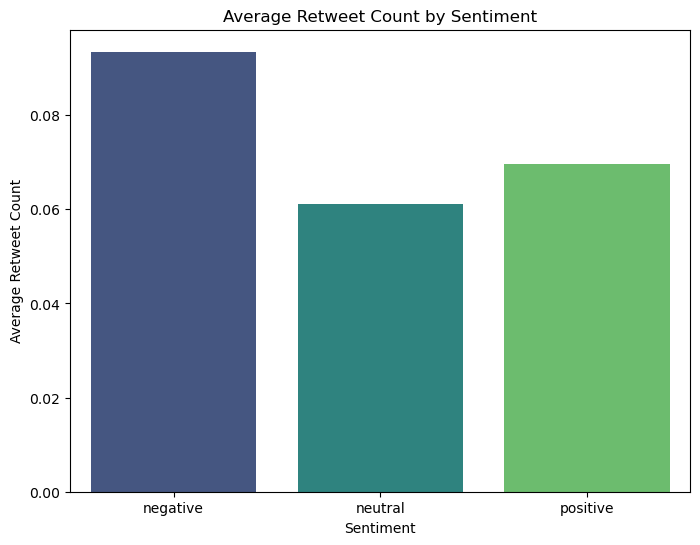

In [28]:
tweet_retweet_sentiment = df.groupby('airline_sentiment')['retweet_count'].mean().reset_index()
print("\nAverage Retweet Count by Sentiment:")
print(tweet_retweet_sentiment)

plt.figure(figsize=(8, 6))
sns.barplot(x='airline_sentiment', y='retweet_count', data=tweet_retweet_sentiment, palette='viridis')
plt.title('Average Retweet Count by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Retweet Count')
plt.show()

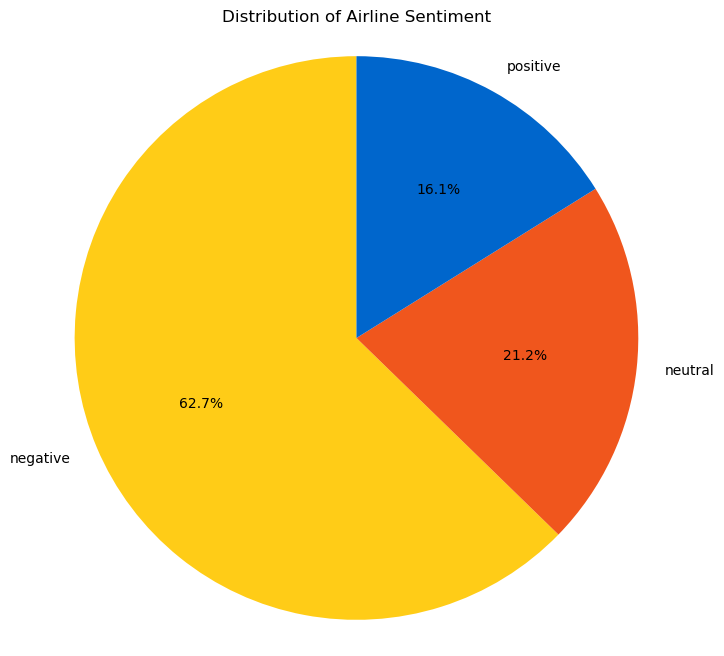

In [29]:
sentiment_counts = df['airline_sentiment'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=90, colors=['#FFCC17', '#F0561D', '#0066CC'])
plt.title('Distribution of Airline Sentiment')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


Negative tweets count by day of the week:
day_of_week
Monday       1922
Tuesday      1600
Wednesday     736
Thursday      751
Friday        835
Saturday     1049
Sunday       2266
Name: count, dtype: int64


C:\Users\Samson Silvester\AppData\Local\Temp\ipykernel_20788\3238460286.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=negative_tweets_by_day.index, y=negative_tweets_by_day.values, palette='viridis')


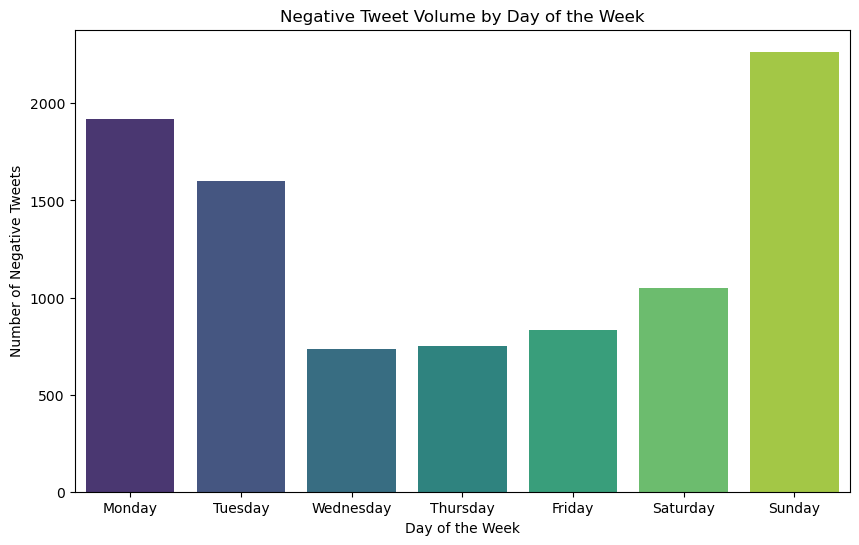


Negative tweets count by hour of the day:
hour_of_day
0      97
1      80
2     109
3     146
4     236
5     313
6     395
7     475
8     556
9     611
10    536
11    566
12    485
13    560
14    585
15    499
16    463
17    451
18    477
19    482
20    389
21    291
22    215
23    142
Name: count, dtype: int64


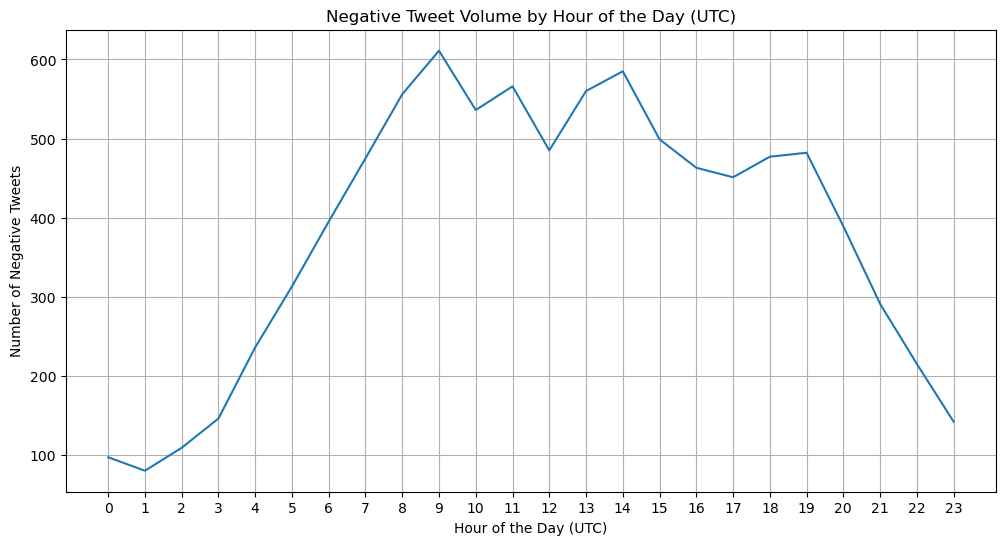


Proportion of negative tweets by day of the week:
day_of_week
Monday       0.633905
Tuesday      0.589102
Wednesday    0.547619
Thursday     0.545785
Friday       0.556667
Saturday     0.673732
Sunday       0.735953
Name: count, dtype: float64


C:\Users\Samson Silvester\AppData\Local\Temp\ipykernel_20788\3238460286.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=negative_proportion_by_day.index, y=negative_proportion_by_day.values, palette='plasma')


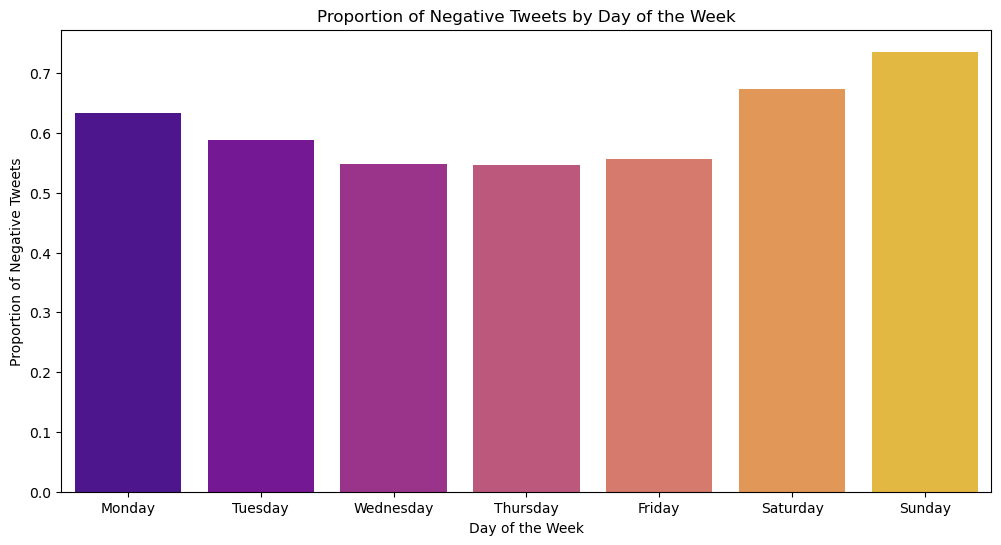


Proportion of negative tweets by hour of the day:
hour_of_day
0     0.740458
1     0.720721
2     0.626437
3     0.648889
4     0.641304
5     0.656184
6     0.636071
7     0.612113
8     0.600432
9     0.611612
10    0.564211
11    0.579918
12    0.588592
13    0.622222
14    0.631068
15    0.633249
16    0.630790
17    0.598143
18    0.635153
19    0.714074
20    0.646179
21    0.676744
22    0.736301
23    0.735751
Name: count, dtype: float64


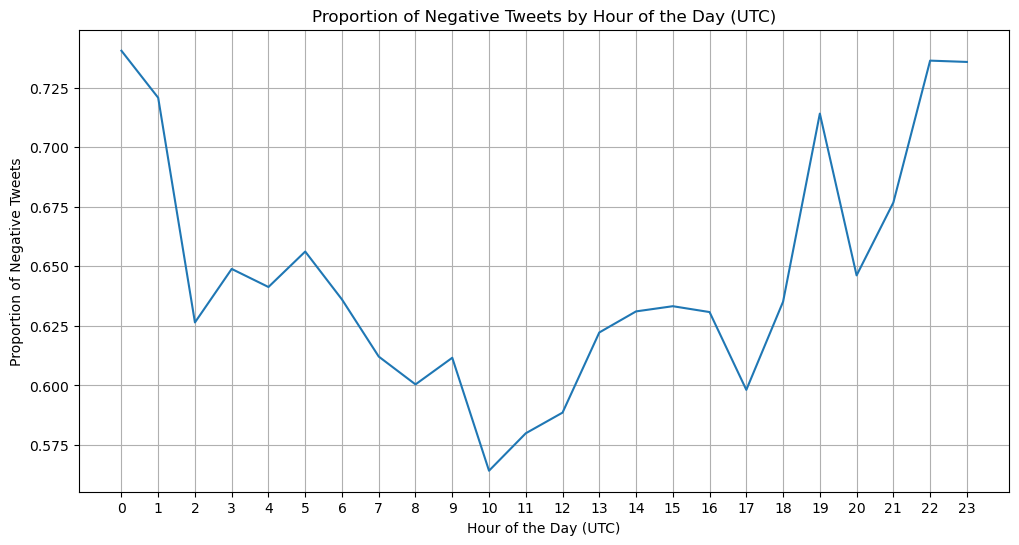

In [30]:
df['tweet_created'] = pd.to_datetime(df['tweet_created'])
negative_tweets_time = df[df['airline_sentiment'] == 'negative'].copy()

# Analyze negative tweets by day of the week
negative_tweets_time['day_of_week'] = negative_tweets_time['tweet_created'].dt.day_name()
negative_tweets_by_day = negative_tweets_time['day_of_week'].value_counts().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

print("\nNegative tweets count by day of the week:")
print(negative_tweets_by_day)

plt.figure(figsize=(10, 6))
sns.barplot(x=negative_tweets_by_day.index, y=negative_tweets_by_day.values, palette='viridis')
plt.title('Negative Tweet Volume by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Negative Tweets')
plt.show()

# Analyze negative tweets by hour of the day (using the hour in UTC as the original data seems to be UTC)
negative_tweets_time['hour_of_day'] = negative_tweets_time['tweet_created'].dt.hour

negative_tweets_by_hour = negative_tweets_time['hour_of_day'].value_counts().sort_index()

print("\nNegative tweets count by hour of the day:")
print(negative_tweets_by_hour)
plt.figure(figsize=(12, 6))
sns.lineplot(x=negative_tweets_by_hour.index, y=negative_tweets_by_hour.values)
plt.title('Negative Tweet Volume by Hour of the Day (UTC)')
plt.xlabel('Hour of the Day (UTC)')
plt.ylabel('Number of Negative Tweets')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

# To see if the _proportion_ of negative tweets changes by time, calculating total tweets by time period as well
all_tweets_time = df.copy()

all_tweets_time['day_of_week'] = all_tweets_time['tweet_created'].dt.day_name()

all_tweets_by_day = all_tweets_time['day_of_week'].value_counts().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

all_tweets_time['hour_of_day'] = all_tweets_time['tweet_created'].dt.hour

all_tweets_by_hour = all_tweets_time['hour_of_day'].value_counts().sort_index()

negative_proportion_by_day = (negative_tweets_by_day / all_tweets_by_day).dropna()
print("\nProportion of negative tweets by day of the week:")
print(negative_proportion_by_day)
plt.figure(figsize=(12, 6))
sns.barplot(x=negative_proportion_by_day.index, y=negative_proportion_by_day.values, palette='plasma')
plt.title('Proportion of Negative Tweets by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Proportion of Negative Tweets')
plt.show()

negative_proportion_by_hour = (negative_tweets_by_hour / all_tweets_by_hour).dropna()
print("\nProportion of negative tweets by hour of the day:")
print(negative_proportion_by_hour)

plt.figure(figsize=(12, 6))
sns.lineplot(x=negative_proportion_by_hour.index, y=negative_proportion_by_hour.values)
plt.title('Proportion of Negative Tweets by Hour of the Day (UTC)')
plt.xlabel('Hour of the Day (UTC)')
plt.ylabel('Proportion of Negative Tweets')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

### Hypothesis Testing

In [31]:
# Null Hypothesis (H0): The frequency of negativereasons is uniformly distributed across all possible negative reasons.
# Alternative Hypothesis (H1): The frequency of negativereasons is not uniformly distributed, with certain reasons being cited significantly more often than others.

from scipy.stats import chi2_contingency
from scipy.stats import chisquare

# Chi-Squared Test for Uniform Distribution of Negative Reasons
observed_frequencies = df['negativereason'].value_counts()
observed_table = pd.DataFrame({'observed': observed_frequencies}).T
total_negative_reasons = observed_frequencies.sum()
num_unique_reasons = len(observed_frequencies)

expected_frequency_per_reason = total_negative_reasons / num_unique_reasons
expected_frequencies = np.full(num_unique_reasons, expected_frequency_per_reason)

chi2_stat, p_value = chisquare(f_obs=observed_frequencies, f_exp=expected_frequencies)


print("\nChi-Squared Test for Uniform Distribution of Negative Reasons")
print(f"Observed Frequencies:\n{observed_frequencies}")
print(f"Expected Frequency (under H0): {expected_frequency_per_reason:.2f} for each reason")
print('\n')
print(f"Chi-squared statistic: {chi2_stat:.4f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"\nConclusion: With a p-value of {p_value:.4f} (less than alpha={alpha}), we reject the null hypothesis.")
    print("There is sufficient evidence to suggest that the frequency of negative reasons is not uniformly distributed.")
else:
    print(f"\nConclusion: With a p-value of {p_value:.4f} (greater than or equal to alpha={alpha}), we fail to reject the null hypothesis.")
    print("There is not enough evidence to suggest that the frequency of negative reasons is not uniformly distributed. The observed distribution is consistent with a uniform distribution.")


Chi-Squared Test for Uniform Distribution of Negative Reasons
Observed Frequencies:
negativereason
Others                         5445
Customer Service Issue         2904
Late Flight                    1660
Can't Tell                     1190
Cancelled Flight                843
Lost Luggage                    721
Bad Flight                      580
Flight Booking Problems         529
Flight Attendant Complaints     480
longlines                       178
Damaged Luggage                  74
Name: count, dtype: int64
Expected Frequency (under H0): 1327.64 for each reason


Chi-squared statistic: 18814.2109
P-value: 0.0000

Conclusion: With a p-value of 0.0000 (less than alpha=0.05), we reject the null hypothesis.
There is sufficient evidence to suggest that the frequency of negative reasons is not uniformly distributed.


In [32]:
# info on dataset
# Which airlines

In [33]:
  # Null Hypothesis (H0): There is no significant difference in the proportion of negative (or positive) sentiment tweets across different airlines.
  # Alternative Hypothesis (H1): There is a significant difference in the proportion of negative (or positive) sentiment tweets among different airlines.

  contingency_table = pd.crosstab(df['airline'], df['airline_sentiment'])
  print("\nContingency Table (Airline vs. Sentiment):")
  print(contingency_table)
  chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

  print("\nChi-Squared Test for Independence (Airline vs. Sentiment)")
  print(f"Chi-squared statistic: {chi2_stat:.4f}")
  print(f"P-value: {p_value:.4f}")
  print(f"Degrees of Freedom: {dof}")

  alpha = 0.05  
  if p_value < alpha:
     print(f"\nConclusion: With a p-value of {p_value:.4f} (less than alpha={alpha}), we reject the null hypothesis (H0).")
     print("There is sufficient evidence to suggest that there is a significant difference in the proportion of sentiment tweets across different airlines.")
  else:
     print(f"\nConclusion: With a p-value of {p_value:.4f} (greater than or equal to alpha={alpha}), we fail to reject the null hypothesis (H0).")
     print("There is not enough evidence to suggest a significant difference in the proportion of sentiment tweets across different airlines. The observed distribution is consistent with independence between    airline and sentiment.")


Contingency Table (Airline vs. Sentiment):
airline_sentiment  negative  neutral  positive
airline                                       
American               1941      455       327
Delta                   955      723       544
Southwest              1186      664       570
US Airways             2263      381       269
United                 2633      697       492
Virgin America          181      171       152

Chi-Squared Test for Independence (Airline vs. Sentiment)
Chi-squared statistic: 1158.2455
P-value: 0.0000
Degrees of Freedom: 10

Conclusion: With a p-value of 0.0000 (less than alpha=0.05), we reject the null hypothesis (H0).
There is sufficient evidence to suggest that there is a significant difference in the proportion of sentiment tweets across different airlines.


In [34]:
# Null Hypothesis (H0): There is no statistical correlation between airline_sentiment_confidence and the likelihood of a tweet being negative.
# Alternative Hypothesis (H1): There is a statistical correlation between airline_sentiment_confidence and the likelihood of a tweet being negative.
from scipy.stats import pearsonr
correlation, p_value_correlation = pearsonr(df['airline_sentiment_confidence'], df['is_negative'])

print("\nFormal Test for Correlation between Airline Sentiment Confidence and Likelihood of being Negative")
print(f"Pearson correlation coefficient: {correlation:.4f}")
print(f"P-value for the correlation test: {p_value_correlation:.4f}")

alpha = 0.05
if p_value_correlation < alpha:
  print(f"\nConclusion: With a p-value of {p_value_correlation:.4f} (less than alpha={alpha}), we reject the null hypothesis (H0).")
  print("There is sufficient evidence to suggest a statistically significant correlation between airline_sentiment_confidence and the likelihood of a tweet being negative.")
else:
  print(f"\nConclusion: With a p-value of {p_value_correlation:.4f} (greater than or equal to alpha={alpha}), we fail to reject the null hypothesis (H0).")
  print("There is not enough evidence to suggest a statistically significant correlation between airline_sentiment_confidence and the likelihood of a tweet being negative.")

if abs(correlation) >= 0.5:
  strength = "strong"
elif abs(correlation) >= 0.3:
    strength = "moderate"
elif abs(correlation) >= 0.1:
    strength = "weak"
else:
    strength = "very weak or no"

direction = "positive" if correlation > 0 else "negative" if correlation < 0 else "no"
print(f"The correlation coefficient ({correlation:.4f}) indicates a {strength} {direction} linear relationship.")


Formal Test for Correlation between Airline Sentiment Confidence and Likelihood of being Negative
Pearson correlation coefficient: 0.2651
P-value for the correlation test: 0.0000

Conclusion: With a p-value of 0.0000 (less than alpha=0.05), we reject the null hypothesis (H0).
There is sufficient evidence to suggest a statistically significant correlation between airline_sentiment_confidence and the likelihood of a tweet being negative.
The correlation coefficient (0.2651) indicates a weak positive linear relationship.


In [35]:
# Null Hypothesis (H0): The distribution of sentiment (negative/positive) for a given airline is independent of tweet_location and user_timezone.
# Alternative Hypothesis (H1): The distribution of sentiment (negative/positive) for a given airline is dependent on tweet_location or user_timezone, indicating a higher concentration of specific sentiments in   certain areas/timezones.

negative_df = df[df['airline_sentiment'] == 'negative'].copy()
min_timezone_negative_tweets = 50
min_negativereason_count = 20

timezone_reason_contingency = pd.crosstab(negative_df['user_timezone'], negative_df['negativereason'])
timezone_reason_contingency_filtered_tz = timezone_reason_contingency[timezone_reason_contingency.sum(axis=1) >= min_timezone_negative_tweets]

timezone_reason_contingency_filtered = timezone_reason_contingency_filtered_tz.loc[:, timezone_reason_contingency_filtered_tz.sum(axis=0) >= min_negativereason_count]

print("\nContingency Table (User Timezone vs. Negative Reason - filtered):")
print(timezone_reason_contingency_filtered.head()) # Print head as the table can be large

if not timezone_reason_contingency_filtered.empty and timezone_reason_contingency_filtered.shape[0] > 1 and timezone_reason_contingency_filtered.shape[1] > 1:
    print("\nPerforming Chi-Squared Test for Independence (User Timezone vs. Negative Reason)")
    chi2_stat, p_value, dof, expected = chi2_contingency(timezone_reason_contingency_filtered)

    print(f"Chi-squared statistic: {chi2_stat:.4f}")
    print(f"P-value: {p_value:.4f}")
    print(f"Degrees of Freedom: {dof}")

    alpha = 0.05
    if p_value < alpha:
       print(f"\nConclusion: With a p-value of {p_value:.4f} (less than alpha={alpha}), we reject the null hypothesis (H0).")
       print("There is sufficient evidence to suggest that the distribution of common negative reasons varies significantly by user_timezone.")
    else:
       print(f"\nConclusion: With a p-value of {p_value:.4f} (greater than or equal to alpha={alpha}), we fail to reject the null hypothesis (H0).")
       print("There is not enough evidence to suggest that the distribution of common negative reasons varies significantly by user_timezone. The observed distribution is consistent with independence.")
else:
    print("\nNot enough data in the filtered contingency table (User Timezone vs. Negative Reason) to perform a reliable Chi-Squared test.")
    print(f"Filtered table shape: {timezone_reason_contingency_filtered.shape}")


Contingency Table (User Timezone vs. Negative Reason - filtered):
negativereason              Bad Flight  Can't Tell  Cancelled Flight  \
user_timezone                                                          
Alaska                               0          12                 9   
Arizona                             16          19                 8   
Atlantic Time (Canada)              16          32                29   
Central Time (US & Canada)          72         137               139   
Eastern Time (US & Canada)         138         290               224   

negativereason              Customer Service Issue  Damaged Luggage  \
user_timezone                                                         
Alaska                                          30                0   
Arizona                                         43                1   
Atlantic Time (Canada)                          92                1   
Central Time (US & Canada)                     390                7   
Ea

In [36]:
min_location_tweets = 50
print("\nTesting Sentiment Performance across Geographic Areas (Tweet Location) for each Airline")

for airline_name in df['airline'].unique():
    print(f"\nAnalyzing Sentiment Performance for {airline_name} across Tweet Locations:")
    airline_df = df[df['airline'] == airline_name].copy()
    location_sentiment_contingency = pd.crosstab(airline_df['tweet_location'], airline_df['airline_sentiment'])
    location_sentiment_contingency_filtered = location_sentiment_contingency[location_sentiment_contingency.sum(axis=1) >= min_location_tweets]
    if not location_sentiment_contingency_filtered.empty and location_sentiment_contingency_filtered.shape[0] > 1 and location_sentiment_contingency_filtered.shape[1] > 1:
       print(f"Performing Chi-Squared test for {airline_name} (filtered for locations with >= {min_location_tweets} tweets)")
       chi2_stat, p_value, dof, expected = chi2_contingency(location_sentiment_contingency_filtered)

    print(f"Chi-squared statistic: {chi2_stat:.4f}")
    print(f"P-value: {p_value:.4f}")
    print(f"Degrees of Freedom: {dof}")

    alpha = 0.05
    if p_value < alpha:
      print(f"\nConclusion for {airline_name}: With a p-value of {p_value:.4f} (less than alpha={alpha}), we reject the null hypothesis (H0).")
      print(f"There is sufficient evidence to suggest that the sentiment performance for {airline_name} varies significantly across different tweet_locations.")
    else:
       print(f"\nConclusion for {airline_name}: With a p-value of {p_value:.4f} (greater than or equal to alpha={alpha}), we fail to reject the null hypothesis (H0).")
       print(f"There is not enough evidence to suggest a significant variation in sentiment performance for {airline_name} across different tweet_locations. The observed distribution is consistent with sentiment        performance being independent of location.")
else:
    print(f"Not enough data for {airline_name} in the filtered contingency table (Tweet Location vs. Sentiment) to perform a reliable Chi-Squared test.")
    print(f"Filtered table shape: {location_sentiment_contingency_filtered.shape}")


Testing Sentiment Performance across Geographic Areas (Tweet Location) for each Airline

Analyzing Sentiment Performance for Virgin America across Tweet Locations:
Chi-squared statistic: 189.7244
P-value: 0.0000
Degrees of Freedom: 90

Conclusion for Virgin America: With a p-value of 0.0000 (less than alpha=0.05), we reject the null hypothesis (H0).
There is sufficient evidence to suggest that the sentiment performance for Virgin America varies significantly across different tweet_locations.

Analyzing Sentiment Performance for United across Tweet Locations:
Chi-squared statistic: 189.7244
P-value: 0.0000
Degrees of Freedom: 90

Conclusion for United: With a p-value of 0.0000 (less than alpha=0.05), we reject the null hypothesis (H0).
There is sufficient evidence to suggest that the sentiment performance for United varies significantly across different tweet_locations.

Analyzing Sentiment Performance for Southwest across Tweet Locations:
Chi-squared statistic: 189.7244
P-value: 0.000

In [37]:
min_tweets_for_chi2 = 100
timezone_sentiment_contingency = pd.crosstab(df['user_timezone'], df['airline_sentiment'])
timezone_sentiment_contingency_filtered = timezone_sentiment_contingency[timezone_sentiment_contingency.sum(axis=1) >= min_tweets_for_chi2]
print("\nContingency Table (User Timezone vs. Sentiment - filtered for timezones with >= {} tweets):".format(min_tweets_for_chi2))
print(timezone_sentiment_contingency_filtered.head())

# Performing the Chi-Squared Test for Independence
if not timezone_sentiment_contingency_filtered.empty and timezone_sentiment_contingency_filtered.shape[0] > 1 and timezone_sentiment_contingency_filtered.shape[1] > 1:
    chi2_stat_sentiment, p_value_sentiment, dof_sentiment, expected_sentiment = chi2_contingency(timezone_sentiment_contingency_filtered)

    print("\nChi-Squared Test for Independence (User Timezone vs. Sentiment Distribution)")
    print(f"Chi-squared statistic: {chi2_stat_sentiment:.4f}")
    print(f"P-value: {p_value_sentiment:.4f}")
    print(f"Degrees of Freedom: {dof_sentiment}")

    alpha = 0.05
    if p_value_sentiment < alpha:
      print(f"\nConclusion: With a p-value of {p_value_sentiment:.4f} (less than alpha={alpha}), we reject the null hypothesis (H0).")
      print("There is sufficient evidence to suggest that the sentiment distribution differs significantly across user timezones.")
    else:
      print(f"\nConclusion: With a p-value of {p_value_sentiment:.4f} (greater than or equal to alpha={alpha}), we fail to reject the null hypothesis (H0).")
      print("There is not enough evidence to suggest a significant difference in sentiment distribution across user timezones. The observed distribution is consistent with sentiment distribution being   independent of timezone.")
else:
    print("\nNot enough data in the filtered contingency table (User Timezone vs. Sentiment) to perform a reliable Chi-Squared test.")
    print(f"Filtered table shape: {timezone_sentiment_contingency_filtered.shape}")

# Test 2: Chi-Squared Test for Uniform Distribution of Tweet Volume across Timezones (considering only significant timezones)
timezone_tweet_volume_filtered = timezone_sentiment_contingency_filtered.sum(axis=1)

if not timezone_tweet_volume_filtered.empty and len(timezone_tweet_volume_filtered) > 1:
    observed_tweet_volumes = timezone_tweet_volume_filtered.values
    total_volume_filtered = observed_tweet_volumes.sum()
    num_timezones_filtered = len(observed_tweet_volumes)
    expected_volume_per_timezone = total_volume_filtered / num_timezones_filtered
    expected_tweet_volumes = np.full(num_timezones_filtered, expected_volume_per_timezone)

    # Perform the Chi-Squared Test for Uniformity
    chi2_stat_volume, p_value_volume = chisquare(f_obs=observed_tweet_volumes, f_exp=expected_tweet_volumes)

    print("\nChi-Squared Test for Uniform Distribution of Tweet Volume across Filtered User Timezones")
    print(f"Observed Tweet Volumes:\n{timezone_tweet_volume_filtered.head()}") # Print head as this can be long
    print(f"Expected Tweet Volume (under H0): {expected_volume_per_timezone:.2f} for each timezone")
    print('\n')
    print(f"Chi-squared statistic: {chi2_stat_volume:.4f}")
    print(f"P-value: {p_value_volume:.4f}")
    alpha = 0.05
    if p_value_volume < alpha:
      print(f"\nConclusion: With a p-value of {p_value_volume:.4f} (less than alpha={alpha}), we reject the null hypothesis.")
      print("There is sufficient evidence to suggest that the tweet volume is not uniformly distributed across the filtered user timezones.")
    else:
      print(f"\nConclusion: With a p-value of {p_value_volume:.4f} (greater than or equal to alpha={alpha}), we fail to reject the null hypothesis.")
      print("There is not enough evidence to suggest that the tweet volume is not uniformly distributed across the filtered user timezones. The observed distribution is consistent with a uniform distribution.")

else:
      print("\nNot enough data in the filtered list of timezones to perform a reliable Chi-Squared test for uniform volume.")
      print(f"Number of filtered timezones: {len(timezone_tweet_volume_filtered)}")

print("\nOverall Hypothesis Test Conclusion (Timezone vs. Tweet Volume and Sentiment)")
alpha = 0.05
if p_value_sentiment < alpha or p_value_volume < alpha:
    print("Based on the Chi-Squared tests for sentiment distribution and tweet volume, we reject the Null Hypothesis (H0).")
    print("There is significant evidence to suggest that the volume of tweets and/or the sentiment distribution differ across user_timezones.")
else:
    print("Based on the Chi-Squared tests, we fail to reject the Null Hypothesis (H0).")
    print("There is not enough evidence to suggest that the volume of tweets or the sentiment distribution differ significantly across user_timezones.")


Contingency Table (User Timezone vs. Sentiment - filtered for timezones with >= 100 tweets):
airline_sentiment           negative  neutral  positive
user_timezone                                          
Alaska                            73       18        17
Arizona                          134       57        37
Atlantic Time (Canada)           299      119        78
Central Time (US & Canada)      1188      380       355
Eastern Time (US & Canada)      2310      769       659

Chi-Squared Test for Independence (User Timezone vs. Sentiment Distribution)
Chi-squared statistic: 287.9421
P-value: 0.0000
Degrees of Freedom: 22

Conclusion: With a p-value of 0.0000 (less than alpha=0.05), we reject the null hypothesis (H0).
There is sufficient evidence to suggest that the sentiment distribution differs significantly across user timezones.

Chi-Squared Test for Uniform Distribution of Tweet Volume across Filtered User Timezones
Observed Tweet Volumes:
user_timezone
Alaska                

In [38]:
# Null Hypothesis (H0): There is no significant difference in the mean retweet_count among tweets with positive, neutral, and negative sentiments.
# Alternative Hypothesis (H1): There is a significant difference in the mean retweet_count among tweets with positive, neutral, and negative sentiments.
from scipy.stats import pearsonr
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

model = ols('retweet_count ~ C(airline_sentiment)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2) # typ=2 for unbalanced data
print("\nANOVA Test for Retweet Count by Sentiment:")
print(anova_table)

alpha = 0.05
p_value_anova = anova_table['PR(>F)'][0]
if p_value_anova < alpha:
    print(f"\nConclusion: With a p-value of {p_value_anova:.4f} (less than alpha={alpha}), we reject the null hypothesis (H0).")
    print("There is sufficient evidence to suggest that there is a significant difference in the mean retweet_count among tweets with positive, neutral, and negative sentiments.")

    # Perform Tukey's HSD post-hoc test to see which pairs of sentiments differ
    print("\nPerforming Tukey's HSD Post-Hoc Test:")
    tukey_result = pairwise_tukeyhsd(endog=df['retweet_count'], groups=df['airline_sentiment'], alpha=alpha)
    print(tukey_result)
    print("\nInterpretation of Tukey's HSD:")
    print("The 'reject' column indicates if the difference between the means of the two groups (group1 vs group2) is statistically significant (True means significant difference).")
else:
    print(f"\nConclusion: With a p-value of {p_value_anova:.4f} (greater than or equal to alpha={alpha}), we fail to reject the null hypothesis (H0).")
    print("There is not enough evidence to suggest a significant difference in the mean retweet_count among tweets with positive, neutral, and negative sentiments.")
    correlation_hour_retweet, p_value_hour_retweet = pearsonr(df['tweet_created'].dt.hour, df['retweet_count'])

    print("\nPearson Correlation between Hour of Day (UTC) and Retweet Count")
    print(f"Correlation coefficient: {correlation_hour_retweet:.4f}")
    print(f"P-value: {p_value_hour_retweet:.4f}")

alpha = 0.05
if p_value_hour_retweet < alpha:
    print("Conclusion: Significant linear correlation between hour of day and retweet count.")
else:
    print("Conclusion: No significant linear correlation between hour of day and retweet count.")

# For day of the week and retweet count (ANOVA)
if not df.empty:
    df['day_of_week_num'] = df['tweet_created'].dt.dayofweek # Monday=0, Sunday=6
    day_anova_model = ols('retweet_count ~ C(day_of_week_num)', data=df).fit()
    day_anova_table = sm.stats.anova_lm(day_anova_model, typ=2)

    print("\nANOVA Test for Retweet Count by Day of the Week:")
    print(day_anova_table)

    p_value_day_anova = day_anova_table['PR(>F)'][0]

    if p_value_day_anova < alpha:
        print(f"\nConclusion: With a p-value of {p_value_day_anova:.4f} (less than alpha={alpha}), we reject the null hypothesis (H0).")
        print("There is sufficient evidence to suggest that there is a significant difference in the mean retweet_count across different days of the week.")
    else:
        print(f"\nConclusion: With a p-value of {p_value_day_anova:.4f} (greater than or equal to alpha={alpha}), we fail to reject the null hypothesis (H0).")
        print("There is not enough evidence to suggest a significant difference in the mean retweet_count across different days of the week.")
else:
    print("DataFrame is empty, cannot perform ANOVA by Day of the Week.")

# For timing of tweets and sentiment distribution (Chi-Squared)
# Day of the week vs. Sentiment
contingency_table_day_sentiment = pd.crosstab(df['tweet_created'].dt.day_name(), df['airline_sentiment'])
contingency_table_day_sentiment = contingency_table_day_sentiment.reindex(index=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

if not contingency_table_day_sentiment.empty and contingency_table_day_sentiment.shape[0] > 1 and contingency_table_day_sentiment.shape[1] > 1:
    chi2_stat_day_sentiment, p_value_day_sentiment, dof_day_sentiment, expected_day_sentiment = chi2_contingency(contingency_table_day_sentiment)

    print("\nChi-Squared Test for Independence (Day of Week vs. Sentiment)")
    print(f"Chi-squared statistic: {chi2_stat_day_sentiment:.4f}")
    print(f"P-value: {p_value_day_sentiment:.4f}")
    print(f"Degrees of Freedom: {dof_day_sentiment}")

    alpha = 0.05
    if p_value_day_sentiment < alpha:
        print(f"\nConclusion: With a p-value of {p_value_day_sentiment:.4f} (less than alpha={alpha}), we reject the null hypothesis (H0).")
        print("There is sufficient evidence to suggest that the sentiment distribution differs significantly across different days of the week.")
    else:
        print(f"\nConclusion: With a p-value of {p_value_day_sentiment:.4f} (greater than or equal to alpha={alpha}), we fail to reject the null hypothesis (H0).")
        print("There is not enough evidence to suggest a significant difference in sentiment distribution across different days of the week.")
else:
    print("Not enough data in the contingency table (Day of Week vs. Sentiment) to perform a reliable Chi-Squared test.")
    print(f"Table shape: {contingency_table_day_sentiment.shape}")

# Hour of the day vs. Sentiment
contingency_table_hour_sentiment = pd.crosstab(df['tweet_created'].dt.hour, df['airline_sentiment'])
min_tweets_per_hour = 10
contingency_table_hour_sentiment_filtered = contingency_table_hour_sentiment[contingency_table_hour_sentiment.sum(axis=1) >= min_tweets_per_hour]


if not contingency_table_hour_sentiment_filtered.empty and contingency_table_hour_sentiment_filtered.shape[0] > 1 and contingency_table_hour_sentiment_filtered.shape[1] > 1:
    chi2_stat_hour_sentiment, p_value_hour_sentiment, dof_hour_sentiment, expected_hour_sentiment = chi2_contingency(contingency_table_hour_sentiment_filtered)
    print("\nChi-Squared Test for Independence (Hour of Day vs. Sentiment - filtered)")
    print(f"Chi-squared statistic: {chi2_stat_hour_sentiment:.4f}")
    print(f"P-value: {p_value_hour_sentiment:.4f}")
    print(f"Degrees of Freedom: {dof_hour_sentiment}")

    alpha = 0.05
    if p_value_hour_sentiment < alpha:
        print(f"\nConclusion: With a p-value of {p_value_hour_sentiment:.4f} (less than alpha={alpha}), we reject the null hypothesis (H0).")
        print("There is sufficient evidence to suggest that the sentiment distribution differs significantly across different hours of the day.")
    else:
        print(f"\nConclusion: With a p-value of {p_value_hour_sentiment:.4f} (greater than or equal to alpha={alpha}), we fail to reject the null hypothesis (H0).")
        print("There is not enough evidence to suggest a significant difference in sentiment distribution across different hours of the day.")
else:
    print("\nNot enough data in the filtered contingency table (Hour of Day vs. Sentiment) to perform a reliable Chi-Squared test.")
    print(f"Filtered table shape: {contingency_table_hour_sentiment_filtered.shape}")


ANOVA Test for Retweet Count by Sentiment:
                           sum_sq       df        F   PR(>F)
C(airline_sentiment)     2.896144      2.0  2.59809  0.07445
Residual              8138.016140  14601.0      NaN      NaN

Conclusion: With a p-value of 0.0744 (greater than or equal to alpha=0.05), we fail to reject the null hypothesis (H0).
There is not enough evidence to suggest a significant difference in the mean retweet_count among tweets with positive, neutral, and negative sentiments.

Pearson Correlation between Hour of Day (UTC) and Retweet Count
Correlation coefficient: 0.0284
P-value: 0.0006
Conclusion: Significant linear correlation between hour of day and retweet count.

ANOVA Test for Retweet Count by Day of the Week:
                         sum_sq       df         F    PR(>F)
C(day_of_week_num)     6.074517      6.0  1.816666  0.091599
Residual            8134.837768  14597.0       NaN       NaN

Conclusion: With a p-value of 0.0916 (greater than or equal to alpha=0

C:\Users\Samson Silvester\AppData\Local\Temp\ipykernel_20788\2792759440.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value_anova = anova_table['PR(>F)'][0]
C:\Users\Samson Silvester\AppData\Local\Temp\ipykernel_20788\2792759440.py:49: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value_day_anova = day_anova_table['PR(>F)'][0]


In [39]:
# Null Hypothesis (H0): The proportion of negative sentiment tweets is consistent across different days of the week and times of the day.
# Alternative Hypothesis (H1): The proportion of negative sentiment tweets is significantly higher on certain days of the week or during specific times of the day.

print("\nOverall Hypothesis Test Conclusion (Timing of Negative Sentiment)")
lpha = 0.05
if p_value_day_sentiment < alpha or p_value_hour_sentiment < alpha:
    print("Based on the Chi-Squared tests, we reject the Null Hypothesis (H0).")
    print("There is sufficient evidence to suggest that the proportion of negative sentiment tweets varies significantly across different days of the week and/or times of the day.")
    print("This supports the Alternative Hypothesis (H1) that negative sentiment is significantly higher on certain days or times.")
else:
    print("Based on the Chi-Squared tests, we fail to reject the Null Hypothesis (H0).")
    print("There is not enough evidence to suggest that the proportion of negative sentiment tweets varies significantly across different days of the week or times of the day.")
    print("The observed distribution is consistent with the Null Hypothesis (H0) that the proportion is consistent.")


Overall Hypothesis Test Conclusion (Timing of Negative Sentiment)
Based on the Chi-Squared tests, we reject the Null Hypothesis (H0).
There is sufficient evidence to suggest that the proportion of negative sentiment tweets varies significantly across different days of the week and/or times of the day.
This supports the Alternative Hypothesis (H1) that negative sentiment is significantly higher on certain days or times.


In [40]:
df = pd.read_csv('Tweets.csv')  

### Machine learning approach

In [41]:
df.groupby('airline_sentiment')['text'].count()

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: text, dtype: int64

In [42]:

sentiment_counts = df['airline_sentiment'].value_counts()
fig = px.pie(values=sentiment_counts.values, 
             names=sentiment_counts.index, 
             title='Distribution of Airline Sentiments',
             hole=0.3)
fig.show()

In [43]:
df['text']

0                      @VirginAmerica What @dhepburn said.
1        @VirginAmerica plus you've added commercials t...
2        @VirginAmerica I didn't today... Must mean I n...
3        @VirginAmerica it's really aggressive to blast...
4        @VirginAmerica and it's a really big bad thing...
                               ...                        
14635    @AmericanAir thank you we got on a different f...
14636    @AmericanAir leaving over 20 minutes Late Flig...
14637    @AmericanAir Please bring American Airlines to...
14638    @AmericanAir you have my money, you change my ...
14639    @AmericanAir we have 8 ppl so we need 2 know h...
Name: text, Length: 14640, dtype: object

In [44]:
stop_words = set(stopwords.words('english'))

def comprehensive_clean(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = text.replace('@', '')
    text = re.sub(r'^\w+\s+', '', text)    
    text = re.sub(r'[^\w\s]', '', text)
    words = word_tokenize(text)
    cleaned_words = [w for w in words if w not in stop_words and w.strip() != '']
    return " ".join(cleaned_words).strip()

df['cleaned_text'] = df['text'].apply(comprehensive_clean)

In [45]:
df['cleaned_text']

0                                            dhepburn said
1            plus youve added commercials experience tacky
2             didnt today must mean need take another trip
3        really aggressive blast obnoxious entertainmen...
4                                     really big bad thing
                               ...                        
14635                   thank got different flight chicago
14636    leaving 20 minutes late flight warnings commun...
14637          please bring american airlines blackberry10
14638    money change flight dont answer phones suggest...
14639    8 ppl need 2 know many seats next flight plz p...
Name: cleaned_text, Length: 14640, dtype: object

In [46]:
text_dataframe = df[['cleaned_text', 'airline_sentiment']]
text_dataframe.head()

,cleaned_text,airline_sentiment
0,dhepburn said,neutral
1,plus youve added commercials experience tacky,positive
2,didnt today must mean need take another trip,neutral
3,really aggressive blast obnoxious entertainmen...,negative
4,really big bad thing,negative


In [47]:
text_dataframe['airline_sentiment'].map({'negative': 0, 'neutral': 1, 'positive': 2})

0        1
1        2
2        1
3        0
4        0
        ..
14635    2
14636    0
14637    1
14638    0
14639    1
Name: airline_sentiment, Length: 14640, dtype: int64

In [48]:
X = text_dataframe['cleaned_text']
y = text_dataframe['airline_sentiment']

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [50]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [51]:
f = TfidfVectorizer()
X_train = f.fit_transform(X_train)
X_test = f.transform(X_test)

print(X_train.shape,X_test.shape)

(10248, 12467) (4392, 12467)


In [52]:
X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()

In [53]:
params = {
        'alpha':[0.01, 0.1, 1, 10]
        
        }

gnb = GaussianNB()
clf = GridSearchCV(gnb, params, scoring="f1_weighted", cv=3)

# Fit and predict
gnb.fit(X_train_dense, y_train)
y_pred_gnb = gnb.predict(X_test_dense)

acc_gnb = accuracy_score(y_test, y_pred_gnb)

print(f"Gaussian Naive Bayes Accuracy: {acc_gnb}")
print(classification_report(y_test, y_pred_gnb))

Gaussian Naive Bayes Accuracy: 0.5243624772313297
              precision    recall  f1-score   support

           0       0.80      0.56      0.66      2814
           1       0.31      0.33      0.32       884
           2       0.30      0.63      0.40       694

    accuracy                           0.52      4392
   macro avg       0.47      0.51      0.46      4392
weighted avg       0.62      0.52      0.55      4392



In [54]:
# Multinomial NB

mnb = naive_bayes.MultinomialNB()
clf = GridSearchCV(mnb, params, scoring="f1_weighted", cv=3)

mnb.fit(X_train_dense, y_train)

y_pred_mnb = mnb.predict(X_test_dense)

acc_mnb = accuracy_score(y_test, y_pred_mnb)
print(f"Multinomial Naive Bayes Accuracy: {acc_mnb}")
print(classification_report(y_test, y_pred_mnb))

Multinomial Naive Bayes Accuracy: 0.6971766848816029
              precision    recall  f1-score   support

           0       0.69      1.00      0.81      2814
           1       0.77      0.13      0.23       884
           2       0.92      0.21      0.34       694

    accuracy                           0.70      4392
   macro avg       0.79      0.45      0.46      4392
weighted avg       0.74      0.70      0.62      4392



In [55]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_dense, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression Accuracy:", (y_pred_lr == y_test).mean())
print(classification_report(y_test, y_pred_lr))

# Linear SVM
svm = LinearSVC(max_iter=2000, random_state=42, class_weight='balanced')
svm.fit(X_train_dense, y_train)
y_pred_svm = svm.predict(X_test)
print("\nLinear SVM Accuracy:", (y_pred_svm == y_test).mean())
print(classification_report(y_test, y_pred_svm))

# Random Forest (using dense data)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
rf.fit(X_train_dense, y_train)
y_pred_rf = rf.predict(X_test_dense)
print("\nRandom Forest Accuracy:", (y_pred_rf == y_test).mean())
print(classification_report(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.7711748633879781
              precision    recall  f1-score   support

           0       0.88      0.82      0.85      2814
           1       0.54      0.65      0.59       884
           2       0.70      0.75      0.72       694

    accuracy                           0.77      4392
   macro avg       0.71      0.74      0.72      4392
weighted avg       0.79      0.77      0.78      4392


Linear SVM Accuracy: 0.7802823315118397
              precision    recall  f1-score   support

           0       0.85      0.87      0.86      2814
           1       0.58      0.55      0.57       884
           2       0.71      0.70      0.71       694

    accuracy                           0.78      4392
   macro avg       0.72      0.71      0.71      4392
weighted avg       0.78      0.78      0.78      4392


Random Forest Accuracy: 0.779143897996357
              precision    recall  f1-score   support

           0       0.81      0.91      0.86      2

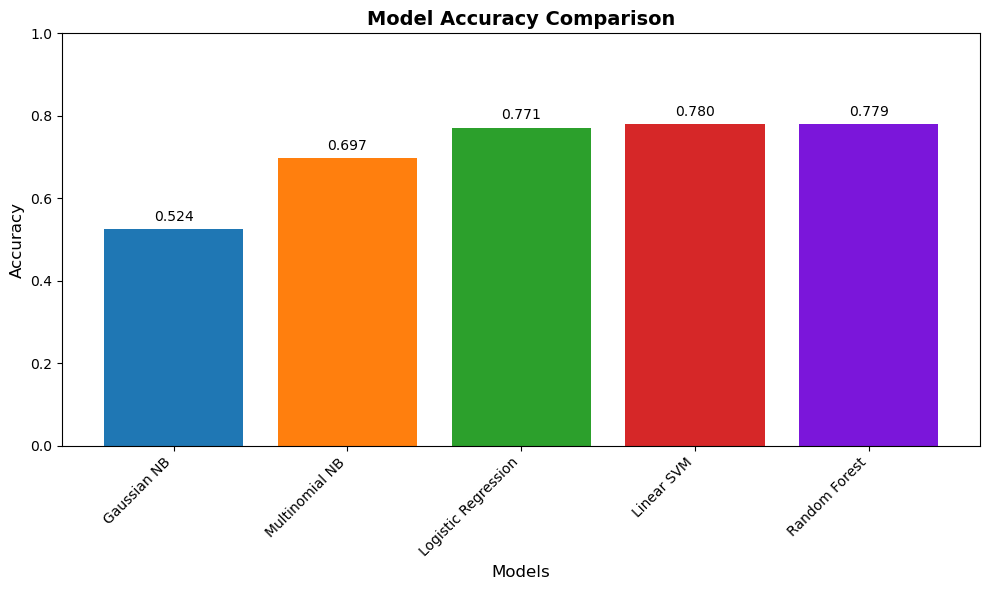

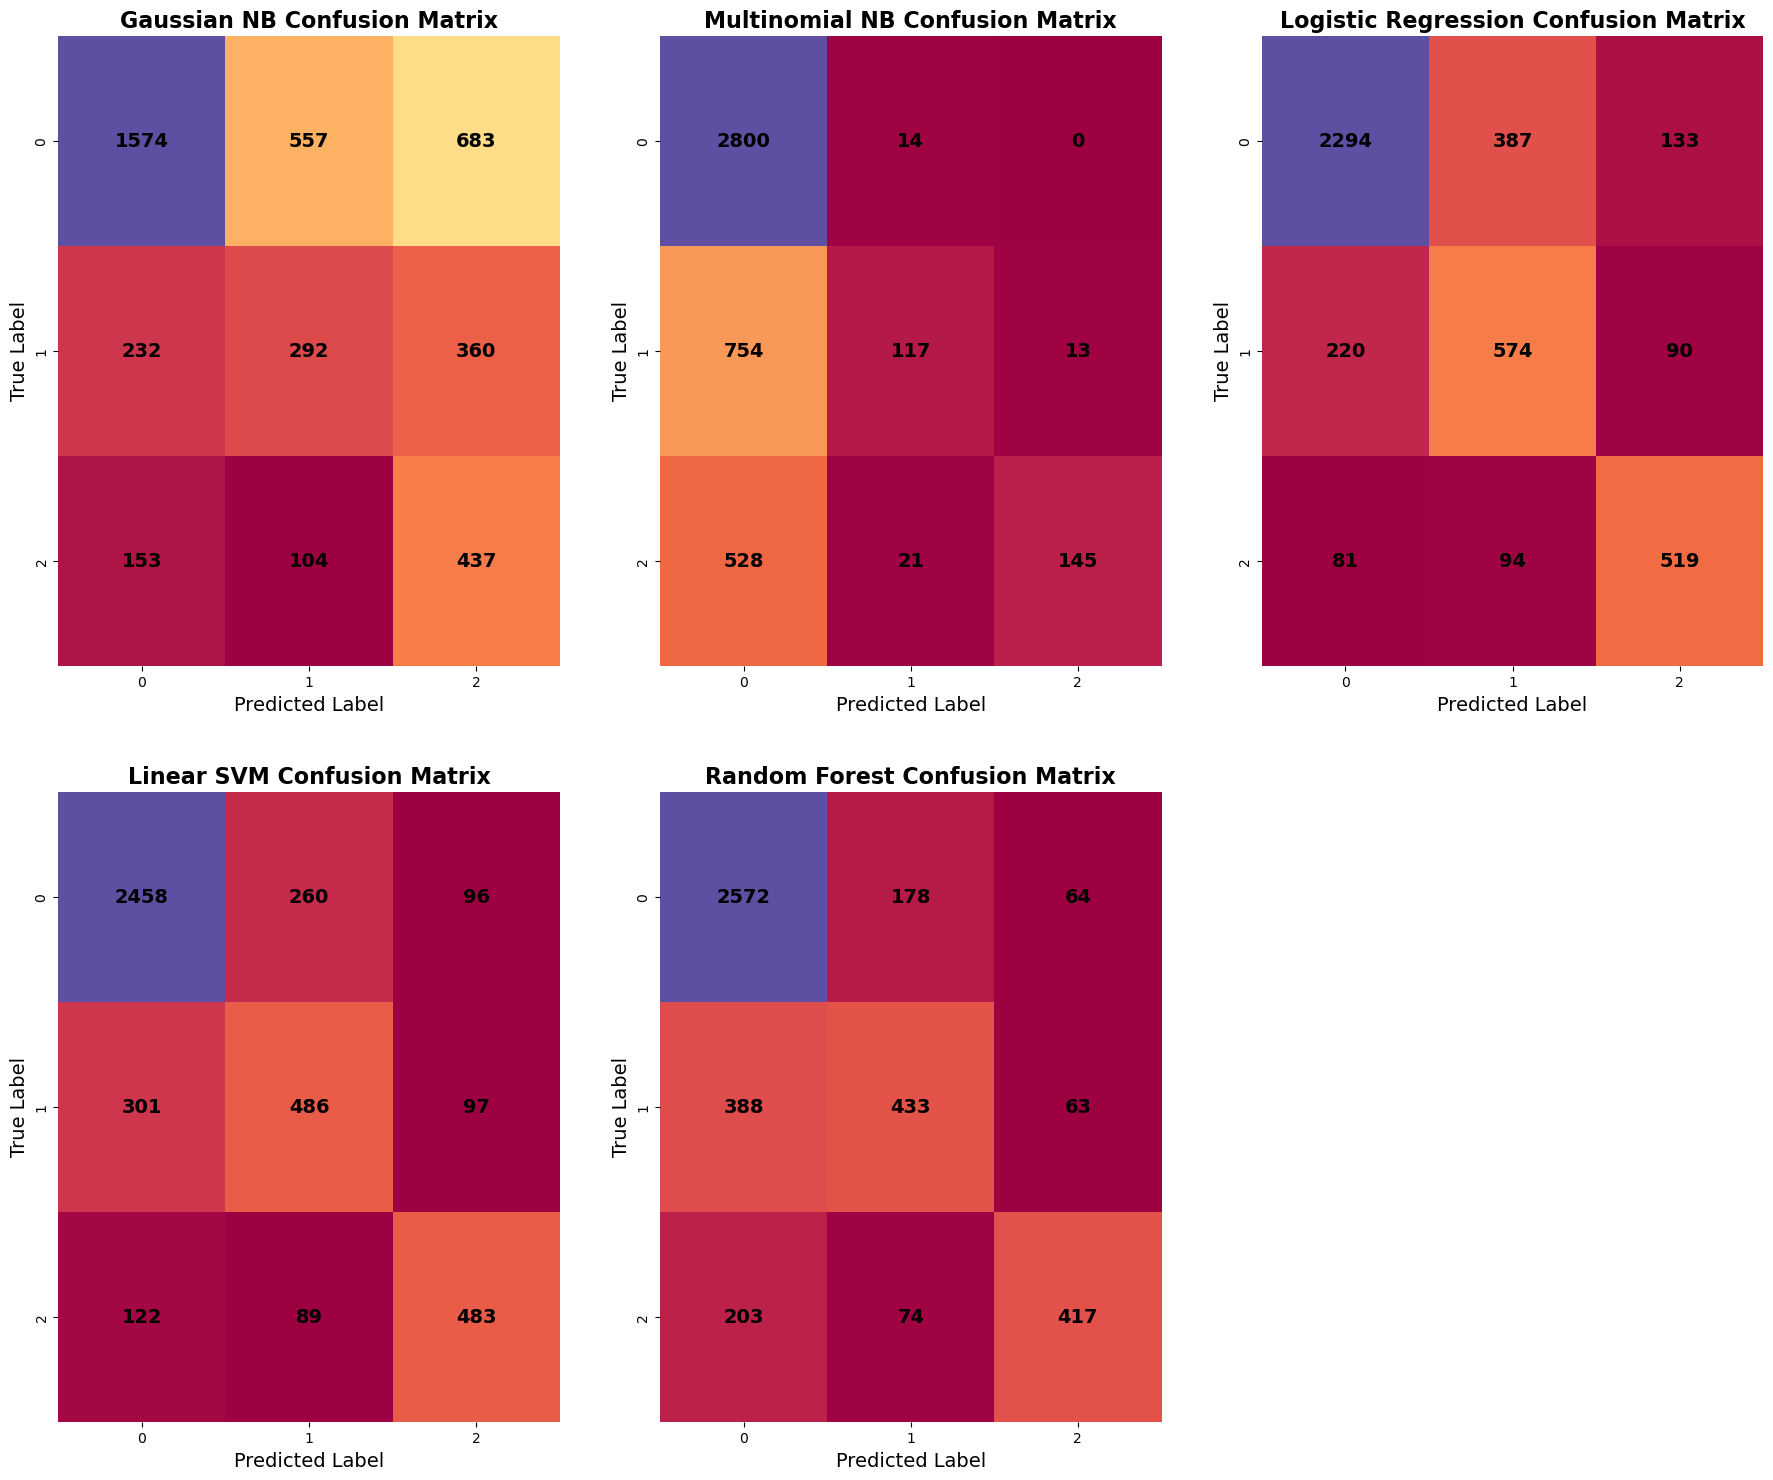

In [56]:
# Create a comparison of all models
models = {
    'Gaussian NB': y_pred_gnb,
    'Multinomial NB': y_pred_mnb,
    'Logistic Regression': y_pred_lr,
    'Linear SVM': y_pred_svm,
    'Random Forest': y_pred_rf
}

accuracies = []
for model_name, y_pred in models.items():
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

# Plot accuracies
plt.figure(figsize=(10, 6))
plt.bar(models.keys(), accuracies, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', "#7b16da"])
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Models', fontsize=12)
plt.ylim([0, 1])
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.02, f'{acc:.3f}', ha='center')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Confusion matrices for each model
fig, axes = plt.subplots(2, 3, figsize=(22, 18)) 
axes = axes.flatten()

for idx, (model_name, y_pred) in enumerate(models.items()):
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', 
                cmap=sns.color_palette("Spectral", as_cmap=True),
                ax=axes[idx], cbar=False,
                annot_kws={"size": 14, "color": "black", "weight": "bold"})
    
    axes[idx].set_title(f'{model_name} Confusion Matrix', fontweight='bold', fontsize=16)
    axes[idx].set_ylabel('True Label', fontsize=14)
    axes[idx].set_xlabel('Predicted Label', fontsize=14)

axes[5].remove()

plt.subplots_adjust(wspace=0.2, hspace=0.2)
plt.show()

### Deep learning approach

In [57]:
X = text_dataframe['cleaned_text']
y = text_dataframe['airline_sentiment']

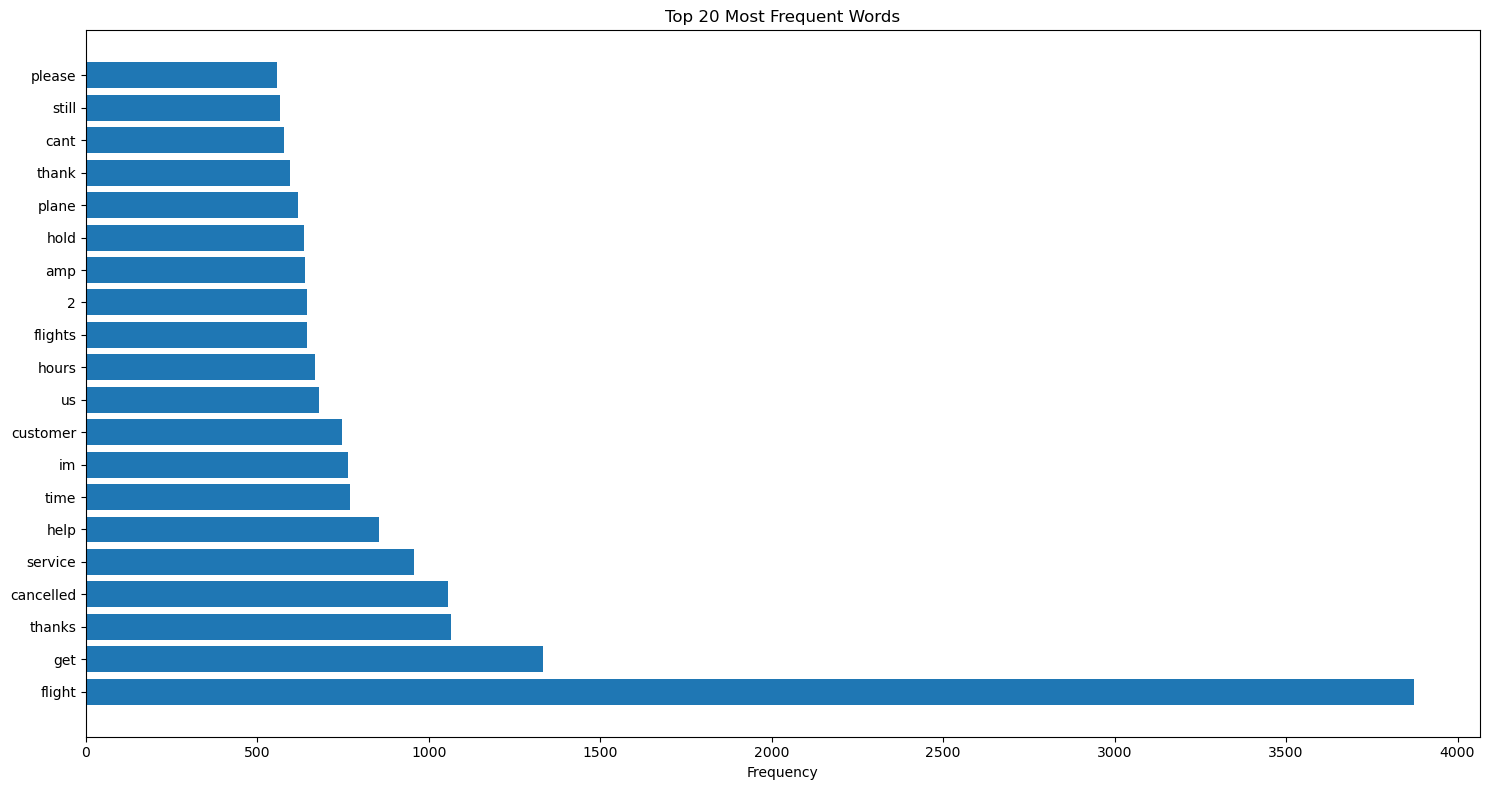

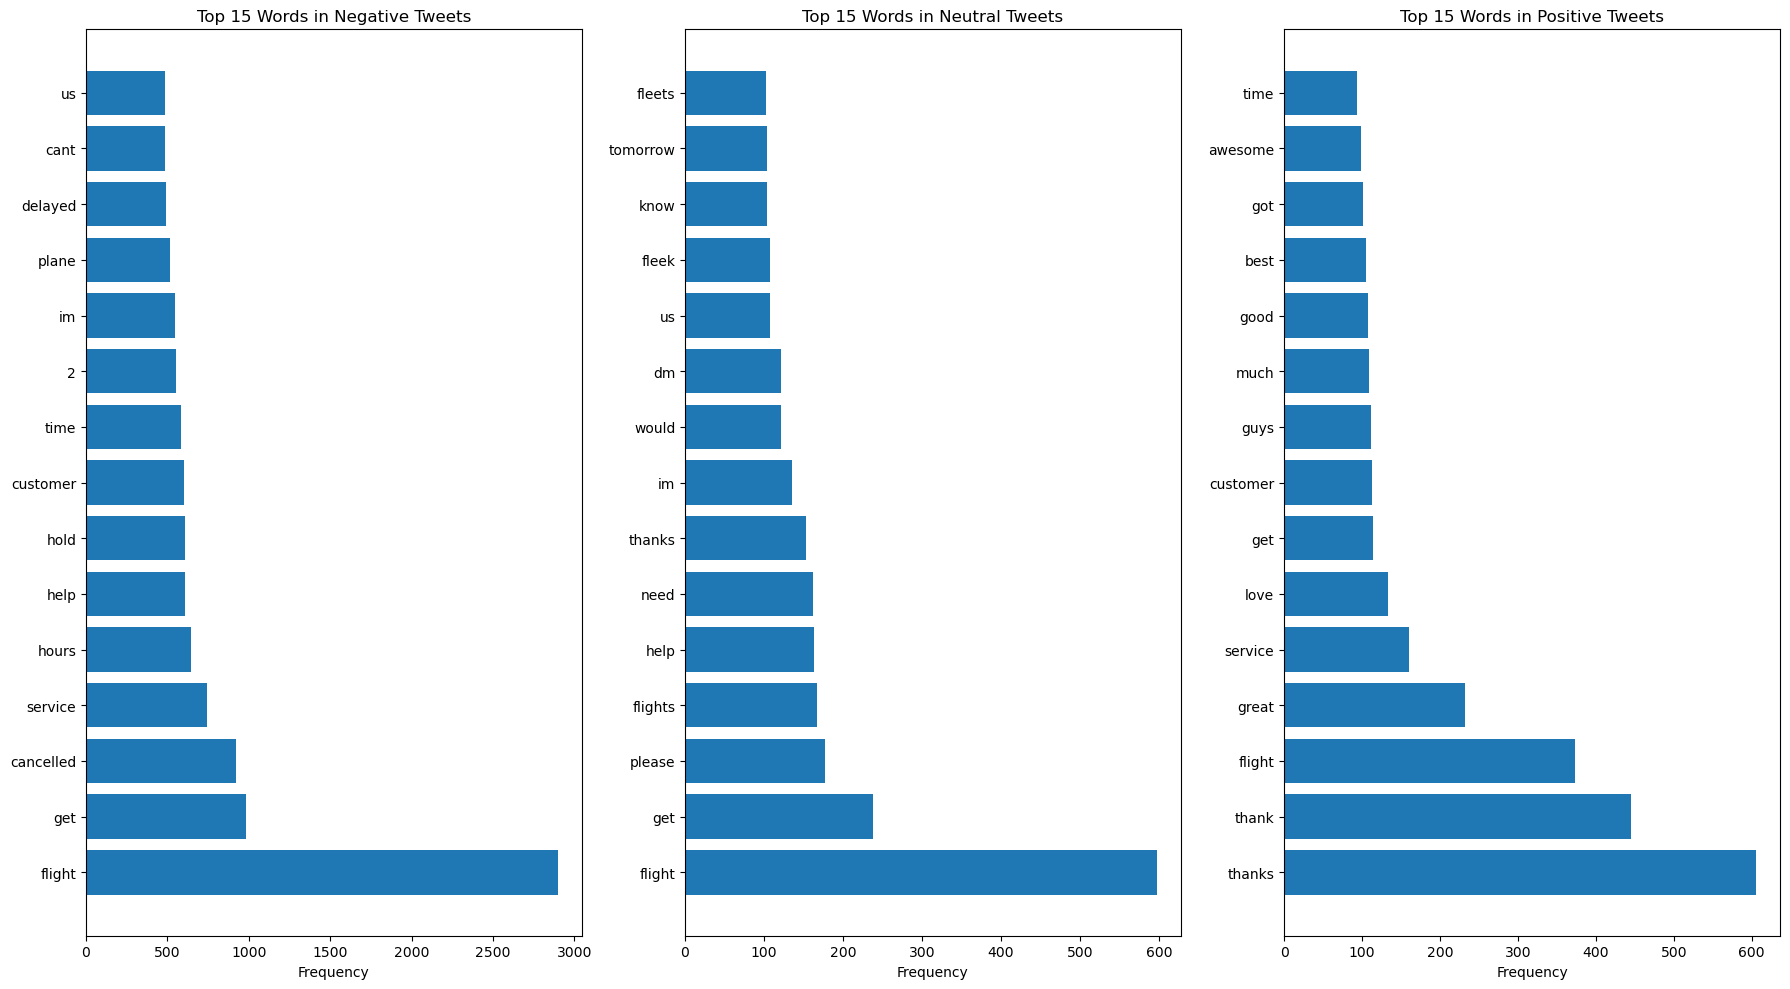

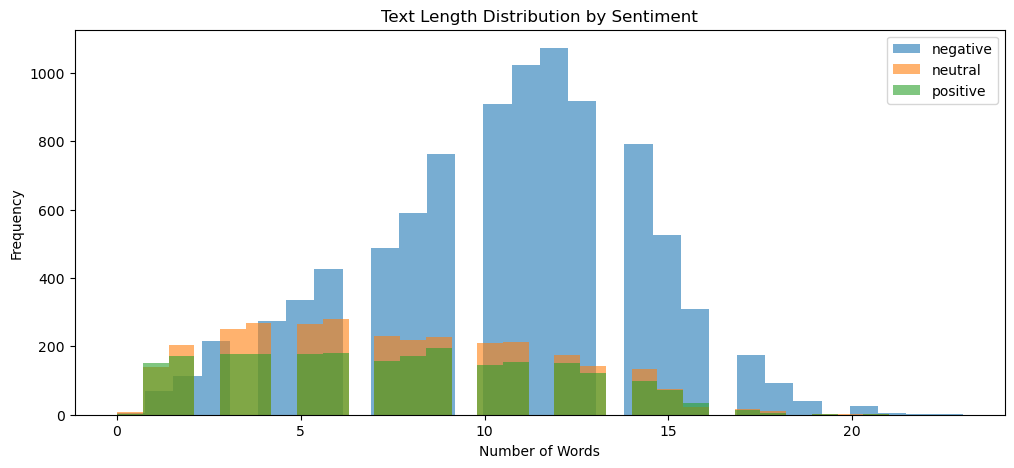

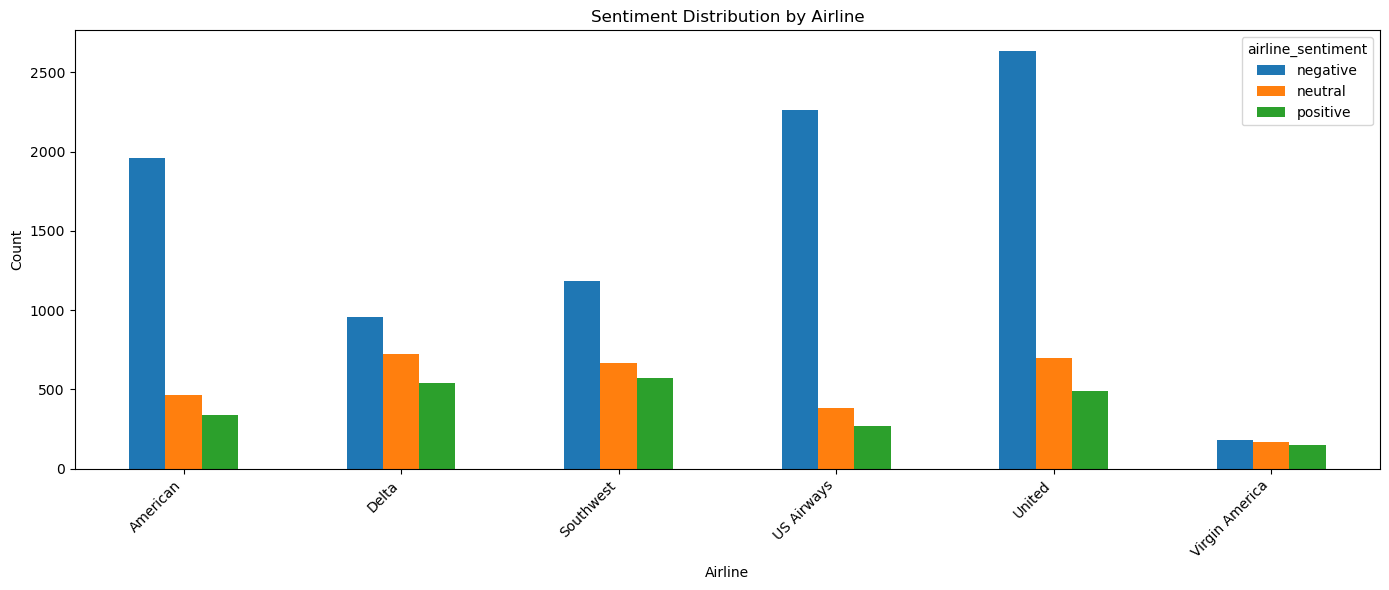

In [58]:
from collections import Counter

# Word frequency analysis

all_words = ' '.join(text_dataframe['cleaned_text']).split()
word_freq = Counter(all_words)
top_words = word_freq.most_common(20)

plt.figure(figsize=(15, 8))
plt.barh([word[0] for word in top_words], [word[1] for word in top_words])
plt.xlabel('Frequency')
plt.title('Top 20 Most Frequent Words')
plt.tight_layout()
plt.show()

# 2. Word frequency by sentiment
fig, axes = plt.subplots(1, 3, figsize=(18, 10))
sentiments = ['negative', 'neutral', 'positive']

for idx, sentiment in enumerate(sentiments):
    sentiment_text = ' '.join(df[df['airline_sentiment'] == sentiment]['cleaned_text'])
    words = sentiment_text.split()
    word_freq_sentiment = Counter(words)
    top_words_sentiment = word_freq_sentiment.most_common(15)
    
    axes[idx].barh([w[0] for w in top_words_sentiment], [w[1] for w in top_words_sentiment])
    axes[idx].set_xlabel('Frequency')
    axes[idx].set_title(f'Top 15 Words in {sentiment.capitalize()} Tweets')

plt.tight_layout()
plt.show()

# 3. Text length analysis by sentiment
df['text_length'] = df['cleaned_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 5))
for sentiment in sentiments:
    data = df[df['airline_sentiment'] == sentiment]['text_length']
    plt.hist(data, alpha=0.6, label=sentiment, bins=30)
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.title('Text Length Distribution by Sentiment')
plt.legend()
plt.show()

# 4. Average sentiment by airline
airline_sentiment = df.groupby('airline')['airline_sentiment'].value_counts().unstack(fill_value=0)
airline_sentiment.plot(kind='bar', figsize=(14, 6))
plt.title('Sentiment Distribution by Airline')
plt.xlabel('Airline')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

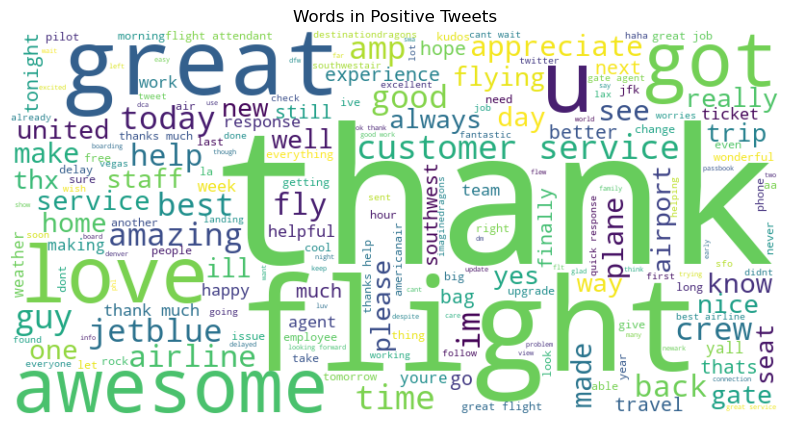

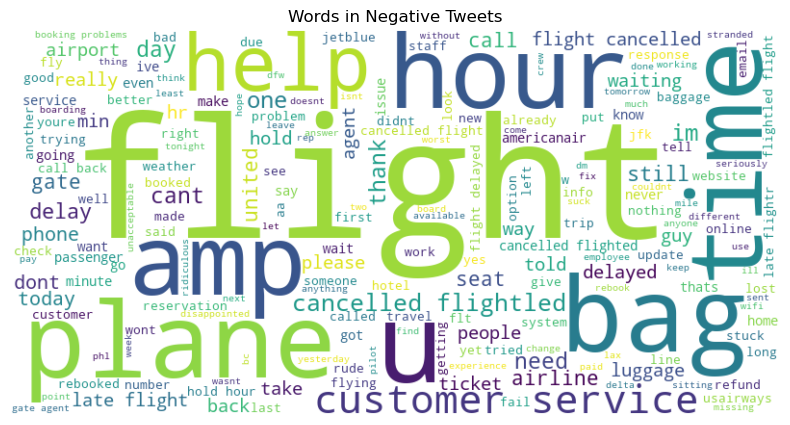

In [59]:
from wordcloud import WordCloud

def show_wordcloud(sentiment_type, title):
    text = " ".join(text_dataframe[text_dataframe['airline_sentiment'] == sentiment_type]['cleaned_text'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title)
    plt.show()

# Visualize positive vs negative
show_wordcloud('positive', 'Words in Positive Tweets')
show_wordcloud('negative', 'Words in Negative Tweets')

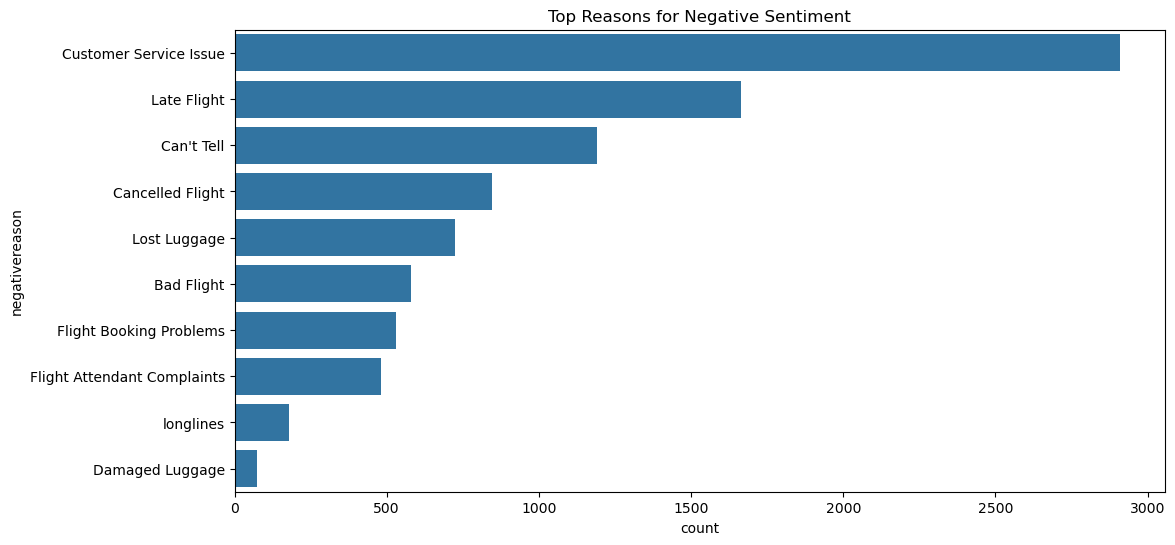

In [60]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, y='negativereason', order=df['negativereason'].value_counts().index)
plt.title('Top Reasons for Negative Sentiment')
plt.show()

In [61]:

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder

# Encoding the target labels (negative, neutral, positive)
le = LabelEncoder()
y = le.fit_transform(text_dataframe['airline_sentiment']) 

# 2. Tokenize the cleaned text
max_words = 5000  # Only consider the top 5000 words
tokenizer = Tokenizer(num_words=max_words, lower=True)
tokenizer.fit_on_texts(text_dataframe['cleaned_text'].values)
sequences = tokenizer.texts_to_sequences(df['cleaned_text'].values)

# 3. Pad sequences so every input has the same length
max_len = 50  # Maximum length of a tweet
X = pad_sequences(sequences, maxlen=max_len)

# 4. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [64]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D


model = Sequential()
model.add(Embedding(max_words, 128, input_length=max_len))
model.add(SpatialDropout1D(0.4))
model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(3, activation='softmax'))

cb_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
batch_size = 32
epochs = 15
history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, 
                    validation_data=(X_test, y_test), verbose=2, callbacks=[cb_callback])

Epoch 1/15


d:\Documents\anaconda\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning:

Argument `input_length` is deprecated. Just remove it.



366/366 - 13s - 37ms/step - accuracy: 0.7063 - loss: 0.7112 - val_accuracy: 0.7896 - val_loss: 0.5383
Epoch 2/15
366/366 - 11s - 31ms/step - accuracy: 0.8137 - loss: 0.4730 - val_accuracy: 0.8050 - val_loss: 0.5122
Epoch 3/15
366/366 - 10s - 26ms/step - accuracy: 0.8558 - loss: 0.3816 - val_accuracy: 0.8023 - val_loss: 0.5309
Epoch 4/15
366/366 - 9s - 25ms/step - accuracy: 0.8767 - loss: 0.3257 - val_accuracy: 0.7985 - val_loss: 0.5583
Epoch 5/15
366/366 - 9s - 25ms/step - accuracy: 0.8946 - loss: 0.2842 - val_accuracy: 0.7886 - val_loss: 0.5965


In [65]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

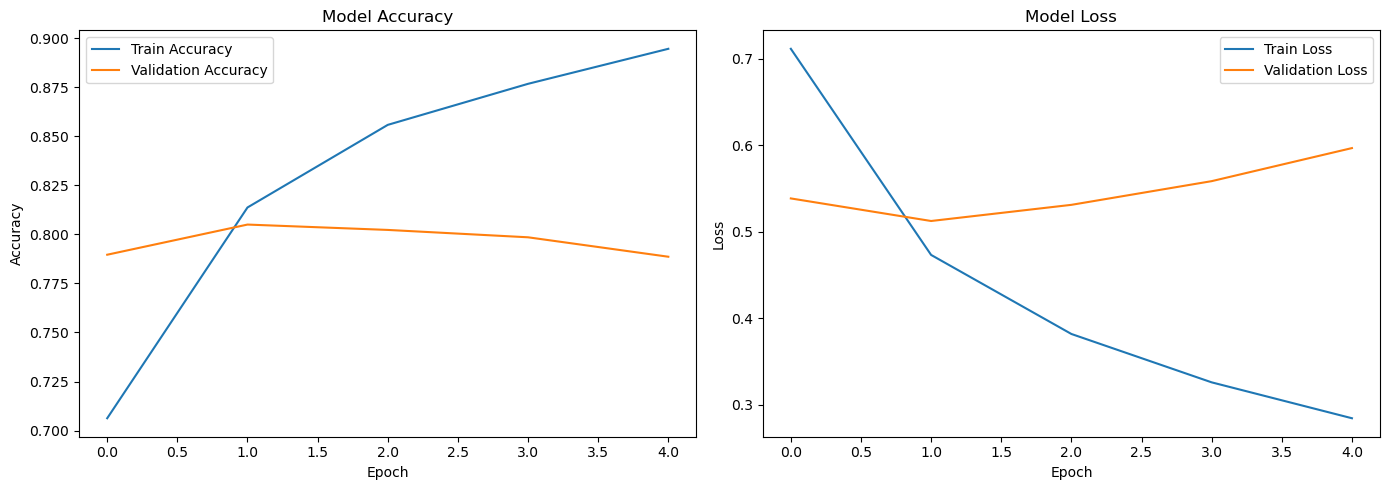

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes.ravel()
ax[0].plot(history.history['accuracy'], label='Train Accuracy')
ax[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
ax[0].set_title('Model Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].legend()

ax[1].plot(history.history['loss'], label='Train Loss')
ax[1].plot(history.history['val_loss'], label='Validation Loss')
ax[1].set_title('Model Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.tight_layout()
plt.show()

In [67]:
def predict_sentiment(text):
    cleaned = comprehensive_clean(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len)
    pred = model.predict(padded)
    return le.inverse_transform([np.argmax(pred)])[0]

# Example Prediction
new_tweet = "The flight was late and the service was terrible."
prediction = predict_sentiment(new_tweet)
print(f"Tweet: {new_tweet} \nPredicted Sentiment: {prediction}")

# To get predictions for the entire test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Evaluation
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=le.classes_))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step
Tweet: The flight was late and the service was terrible. 
Predicted Sentiment: negative
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
              precision    recall  f1-score   support

    negative       0.84      0.92      0.88      1889
     neutral       0.69      0.49      0.57       580
    positive       0.76      0.71      0.73       459

    accuracy                           0.80      2928
   macro avg       0.76      0.71      0.73      2928
weighted avg       0.80      0.80      0.80      2928

